# Peramalan Permintaan GRU V2 (Multi-Skenario)

Notebook ini mengevaluasi performa peramalan GRU menggunakan empat dataset berbeda (Asli + 3 skenario sintetis dari `generate_data_V2.ipynb`). Metrik utama yang digunakan adalah **MAPE** dan **NRMSE** karena keduanya bersifat *scale-independent*, sehingga perbandingan antar dataset dengan skala berbeda menjadi adil.

**Mengapa MAPE & NRMSE?**
- **MAPE (Mean Absolute Percentage Error):** Mengukur galat dalam persen, sehingga tidak terpengaruh oleh besarnya nilai absolut.
- **NRMSE (Normalized RMSE):** RMSE dibagi rentang data (max - min), menghasilkan metrik tanpa satuan yang sebanding antar skala.

In [13]:
import os
import random
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 150

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Output directories
os.makedirs('data/predicted_v2/figures', exist_ok=True)

Using device: cpu


## Gambaran Umum Dataset (Dataset Overview)

In [14]:
# Load original daily demand
df_orig = pd.read_csv('data/processed/cold_chain_data.csv', parse_dates=['order date (DateOrders)'])
df_orig = df_orig.sort_values('order date (DateOrders)')
daily_orig = df_orig.set_index('order date (DateOrders)')['Order Item Quantity'].resample('D').sum().reset_index()
daily_orig.columns = ['Date', 'Demand']

# Load synthetic scenarios
df_normal = pd.read_csv('data/generated_v2/normal_demand.csv', parse_dates=['order date (DateOrders)'])
df_normal.columns = ['Date', 'Demand']

df_moderate = pd.read_csv('data/generated_v2/moderate_volatility.csv', parse_dates=['order date (DateOrders)'])
df_moderate.columns = ['Date', 'Demand']

df_high = pd.read_csv('data/generated_v2/high_volatility.csv', parse_dates=['order date (DateOrders)'])
df_high.columns = ['Date', 'Demand']

datasets = {
    'Original': daily_orig,
    'Normal': df_normal,
    'Moderate': df_moderate,
    'High': df_high
}

print("=== Statistik per Dataset ===")
for name, data in datasets.items():
    print(f"\n[{name}]")
    print(f"  Observasi: {len(data)}")
    print(f"  Rentang: {data['Date'].min().date()} s.d. {data['Date'].max().date()}")
    print(f"  Mean: {data['Demand'].mean():.2f}")
    print(f"  Std: {data['Demand'].std():.2f}")

=== Statistik per Dataset ===

[Original]
  Observasi: 1127
  Rentang: 2015-01-01 s.d. 2018-01-31
  Mean: 340.80
  Std: 101.54

[Normal]
  Observasi: 1492
  Rentang: 2015-01-01 s.d. 2019-01-31
  Mean: 272.70
  Std: 141.43

[Moderate]
  Observasi: 1492
  Rentang: 2015-01-01 s.d. 2019-01-31
  Mean: 268.86
  Std: 147.23

[High]
  Observasi: 1492
  Rentang: 2015-01-01 s.d. 2019-01-31
  Mean: 258.75
  Std: 159.95


## Agregasi Permintaan (Demand Aggregation)

In [15]:
def aggregate_demand(df, freq, label):
    """Aggregate demand to specified frequency."""
    ts = df.set_index('Date')['Demand']
    if freq == 'D':
        agg = ts.resample('D').sum()
    elif freq == 'W':
        agg = ts.resample('W').sum()
    elif freq == 'M':
        agg = ts.resample('ME').sum()
    return agg.reset_index()

# Create all aggregations
all_aggregations = {}
for ds_name, ds_data in datasets.items():
    all_aggregations[ds_name] = {
        'Daily': aggregate_demand(ds_data, 'D', ds_name),
        'Weekly': aggregate_demand(ds_data, 'W', ds_name),
        'Monthly': aggregate_demand(ds_data, 'M', ds_name)
    }
    
    print(f"\n=== {ds_name} ===")
    for gran_name, gran_data in all_aggregations[ds_name].items():
        print(f"  {gran_name}: {len(gran_data)} observasi, Mean={gran_data['Demand'].mean():.2f}")


=== Original ===
  Daily: 1127 observasi, Mean=340.80
  Weekly: 162 observasi, Mean=2370.86
  Monthly: 37 observasi, Mean=10380.51

=== Normal ===
  Daily: 1492 observasi, Mean=272.70
  Weekly: 214 observasi, Mean=1901.25
  Monthly: 49 observasi, Mean=8303.43

=== Moderate ===
  Daily: 1492 observasi, Mean=268.86
  Weekly: 214 observasi, Mean=1874.45
  Monthly: 49 observasi, Mean=8186.39

=== High ===
  Daily: 1492 observasi, Mean=258.75
  Weekly: 214 observasi, Mean=1803.99
  Monthly: 49 observasi, Mean=7878.63


## Eksplorasi Urutan Waktu (Sequence Exploration)

In [16]:
sequence_configs = {
    'Daily': [7, 14, 30],
    'Weekly': [4, 8, 12],
    'Monthly': [3, 6, 12]
}

seq_summary = []
for ds_name in datasets:
    for gran_name, seq_lengths in sequence_configs.items():
        n_obs = len(all_aggregations[ds_name][gran_name])
        for seq in seq_lengths:
            n_samples = max(0, n_obs - seq)
            seq_summary.append({
                'Dataset': ds_name, 'Granularity': gran_name,
                'Sequence Length': seq, 'Generated Samples': n_samples
            })

df_seq = pd.DataFrame(seq_summary)
display(df_seq)

,Dataset,Granularity,Sequence Length,Generated Samples
0,Original,Daily,7,1120
1,Original,Daily,14,1113
2,Original,Daily,30,1097
3,Original,Weekly,4,158
4,Original,Weekly,8,154
5,Original,Weekly,12,150
6,Original,Monthly,3,34
7,Original,Monthly,6,31
8,Original,Monthly,12,25
9,Normal,Daily,7,1485


## Pemodelan GRU (GRU Modeling)

Arsitektur identik dengan GRU-1: Hidden Size 64, Layers 2, Epochs 30, Learning Rate 0.01.
Dengan tambahan *validation loss* untuk mendeteksi *overfitting*.

In [17]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data)-seq_length):
        xs.append(data[i:(i+seq_length)])
        ys.append(data[i+seq_length])
    return np.array(xs), np.array(ys)

def nrmse(actual, predicted):
    """Normalized RMSE: RMSE / (max - min) of actual."""
    rmse_val = np.sqrt(mean_squared_error(actual, predicted))
    range_val = actual.max() - actual.min()
    if range_val == 0:
        return float('inf')
    return rmse_val / range_val

In [18]:
def train_gru_pipeline(df_agg, seq_lengths, dataset_name, gran_name, epochs=30, batch_size=16):
    """Full training pipeline for one dataset + one granularity."""
    results = []
    best_nrmse = float('inf')
    best_info = None
    best_preds = None
    best_model_state = None
    
    values = df_agg['Demand'].values.reshape(-1, 1)
    
    # 80/20 chronological split
    train_size = int(len(values) * 0.8)
    train_data = values[:train_size]
    test_data = values[train_size:]
    
    # MinMaxScaler fit on train only
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)
    
    for seq in seq_lengths:
        X_train, y_train = create_sequences(train_scaled, seq)
        X_test, y_test = create_sequences(test_scaled, seq)
        
        if len(X_train) < 2 or len(X_test) < 2:
            continue
        
        # Split train into train/val (90/10 of train)
        val_split = int(len(X_train) * 0.9)
        X_val, y_val = X_train[val_split:], y_train[val_split:]
        X_train_sub, y_train_sub = X_train[:val_split], y_train[:val_split]
        
        X_train_t = torch.tensor(X_train_sub, dtype=torch.float32)
        y_train_t = torch.tensor(y_train_sub, dtype=torch.float32)
        X_val_t = torch.tensor(X_val, dtype=torch.float32)
        y_val_t = torch.tensor(y_val, dtype=torch.float32)
        X_test_t = torch.tensor(X_test, dtype=torch.float32)
        y_test_t = torch.tensor(y_test, dtype=torch.float32)
        
        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
        
        model = GRUModel().to(device)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        
        train_losses = []
        val_losses = []
        
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            train_losses.append(epoch_loss / len(train_loader))
            
            # Validation loss
            model.eval()
            with torch.no_grad():
                val_out = model(X_val_t.to(device))
                val_loss = criterion(val_out, y_val_t.to(device))
                val_losses.append(val_loss.item())
        
        # Test prediction
        model.eval()
        with torch.no_grad():
            preds_scaled = model(X_test_t.to(device)).cpu().numpy()
        
        preds = scaler.inverse_transform(preds_scaled)
        actuals = scaler.inverse_transform(y_test_t.numpy())
        
        mae = mean_absolute_error(actuals, preds)
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        mape = mean_absolute_percentage_error(actuals, preds)
        r2 = r2_score(actuals, preds)
        nrmse_val = nrmse(actuals.flatten(), preds.flatten())
        
        result = {
            'Dataset': dataset_name, 'Granularity': gran_name,
            'Sequence_Length': seq, 'MAE': mae, 'RMSE': rmse,
            'MAPE': mape, 'NRMSE': nrmse_val, 'R2': r2
        }
        results.append(result)
        
        if nrmse_val < best_nrmse:
            best_nrmse = nrmse_val
            test_dates = df_agg['Date'].iloc[train_size + seq : train_size + seq + len(preds)].values
            best_info = {**result, 'Train_Losses': train_losses, 'Val_Losses': val_losses}
            best_preds = pd.DataFrame({
                'Date': test_dates,
                'Actual': actuals.flatten(),
                'Predicted': preds.flatten()
            })
            best_model_state = model.state_dict().copy()
    
    return results, best_info, best_preds, best_model_state

## Menjalankan Seluruh Eksperimen

In [19]:
all_results = []
all_best_infos = []
all_best_preds = {}
global_best_nrmse = float('inf')
global_best_model_state = None
global_best_info = None

for ds_name, ds_aggs in all_aggregations.items():
    for gran_name, gran_data in ds_aggs.items():
        print(f"Training: {ds_name} - {gran_name}...", end=" ")
        
        results, best_info, best_preds, model_state = train_gru_pipeline(
            gran_data, sequence_configs[gran_name], ds_name, gran_name, epochs=30
        )
        
        all_results.extend(results)
        if best_info:
            all_best_infos.append(best_info)
            all_best_preds[f"{ds_name}_{gran_name}"] = best_preds
            
            if best_info['NRMSE'] < global_best_nrmse:
                global_best_nrmse = best_info['NRMSE']
                global_best_model_state = model_state
                global_best_info = best_info
            
            print(f"Done. Best Seq={best_info['Sequence_Length']}, NRMSE={best_info['NRMSE']:.4f}, MAPE={best_info['MAPE']:.4f}")
        else:
            print("Skipped (insufficient data).")

print("\n=== Seluruh eksperimen selesai ===")

Training: Original - Daily... 

Done. Best Seq=7, NRMSE=0.5448, MAPE=2.4333
Training: Original - Weekly... Done. Best Seq=4, NRMSE=0.6271, MAPE=2.7213
Training: Original - Monthly... Done. Best Seq=3, NRMSE=0.9884, MAPE=3.4347
Training: Normal - Daily... Done. Best Seq=30, NRMSE=0.3603, MAPE=3609079.0000
Training: Normal - Weekly... Done. Best Seq=4, NRMSE=0.5706, MAPE=0.4421
Training: Normal - Monthly... Done. Best Seq=3, NRMSE=17.7153, MAPE=2.1348
Training: Moderate - Daily... Done. Best Seq=7, NRMSE=0.2940, MAPE=50174387772456960.0000
Training: Moderate - Weekly... Done. Best Seq=12, NRMSE=0.9646, MAPE=1.2578
Training: Moderate - Monthly... Done. Best Seq=3, NRMSE=3.3449, MAPE=0.8049
Training: High - Daily... Done. Best Seq=30, NRMSE=0.2535, MAPE=54249895124533248.0000
Training: High - Weekly... Done. Best Seq=12, NRMSE=0.6991, MAPE=0.8545
Training: High - Monthly... Done. Best Seq=6, NRMSE=0.5336, MAPE=0.0493

=== Seluruh eksperimen selesai ===


## Evaluasi (Evaluation)

In [20]:
df_results = pd.DataFrame(all_results)
print("=== Seluruh Hasil Metrik ===")
display(df_results.round(4))

# Best per dataset
print("\n=== Model Terbaik per Dataset (berdasarkan NRMSE) ===")
best_per_dataset = df_results.loc[df_results.groupby('Dataset')['NRMSE'].idxmin()]
display(best_per_dataset[['Dataset', 'Granularity', 'Sequence_Length', 'MAPE', 'NRMSE', 'R2', 'RMSE', 'MAE']].round(4))

# Overall best
print(f"\n=== Model Terbaik Secara Keseluruhan ===")
overall_best = df_results.loc[df_results['NRMSE'].idxmin()]
print(f"Dataset: {overall_best['Dataset']}")
print(f"Granularitas: {overall_best['Granularity']}")
print(f"Sequence Length: {overall_best['Sequence_Length']}")
print(f"MAPE: {overall_best['MAPE']:.4f}")
print(f"NRMSE: {overall_best['NRMSE']:.4f}")
print(f"R²: {overall_best['R2']:.4f}")

# Save results
df_results.to_csv('data/predicted_v2/results.csv', index=False)
best_per_dataset.to_csv('data/predicted_v2/best_model_summary.csv', index=False)
print("\nHasil disimpan.")

=== Seluruh Hasil Metrik ===


,Dataset,Granularity,Sequence_Length,MAE,RMSE,MAPE,NRMSE,R2
0,Original,Daily,7,179.1333,221.7419,2.433300e+00,0.5448,-1.393500e+00
1,Original,Daily,14,189.7860,234.7860,2.615100e+00,0.6558,-1.723900e+00
2,Original,Daily,30,206.1531,246.3785,2.847100e+00,0.6882,-2.119400e+00
3,Original,Weekly,4,1265.3313,1534.4491,2.721300e+00,0.6271,-1.462000e+00
4,Original,Weekly,8,1517.3276,1723.4756,3.283300e+00,0.7043,-2.646400e+00
5,Original,Weekly,12,1648.2451,1749.8850,3.622800e+00,0.7925,-5.672500e+00
6,Original,Monthly,3,7649.2124,8348.7106,3.434700e+00,0.9884,-5.304100e+00
7,Original,Monthly,6,9214.5020,9214.8294,4.339300e+00,9217.0796,-3.398182e+08
8,Normal,Daily,7,56.9621,63.0817,3.945142e+06,0.3711,-3.387700e+00
9,Normal,Daily,14,84.2011,89.2181,4.973860e+06,0.5248,-7.671400e+00



=== Model Terbaik per Dataset (berdasarkan NRMSE) ===


,Dataset,Granularity,Sequence_Length,MAPE,NRMSE,R2,RMSE,MAE
26,High,Daily,30,5.424990e+16,0.2535,-0.6745,63.3731,49.0748
16,Moderate,Daily,7,5.017439e+16,0.2940,-0.9568,62.6212,50.6746
10,Normal,Daily,30,3.609079e+06,0.3603,-2.0295,52.2472,45.6838
0,Original,Daily,7,2.433300e+00,0.5448,-1.3935,221.7419,179.1333



=== Model Terbaik Secara Keseluruhan ===
Dataset: High
Granularitas: Daily
Sequence Length: 30
MAPE: 54249895124533248.0000
NRMSE: 0.2535
R²: -0.6745

Hasil disimpan.


## Visualisasi (Visualization)

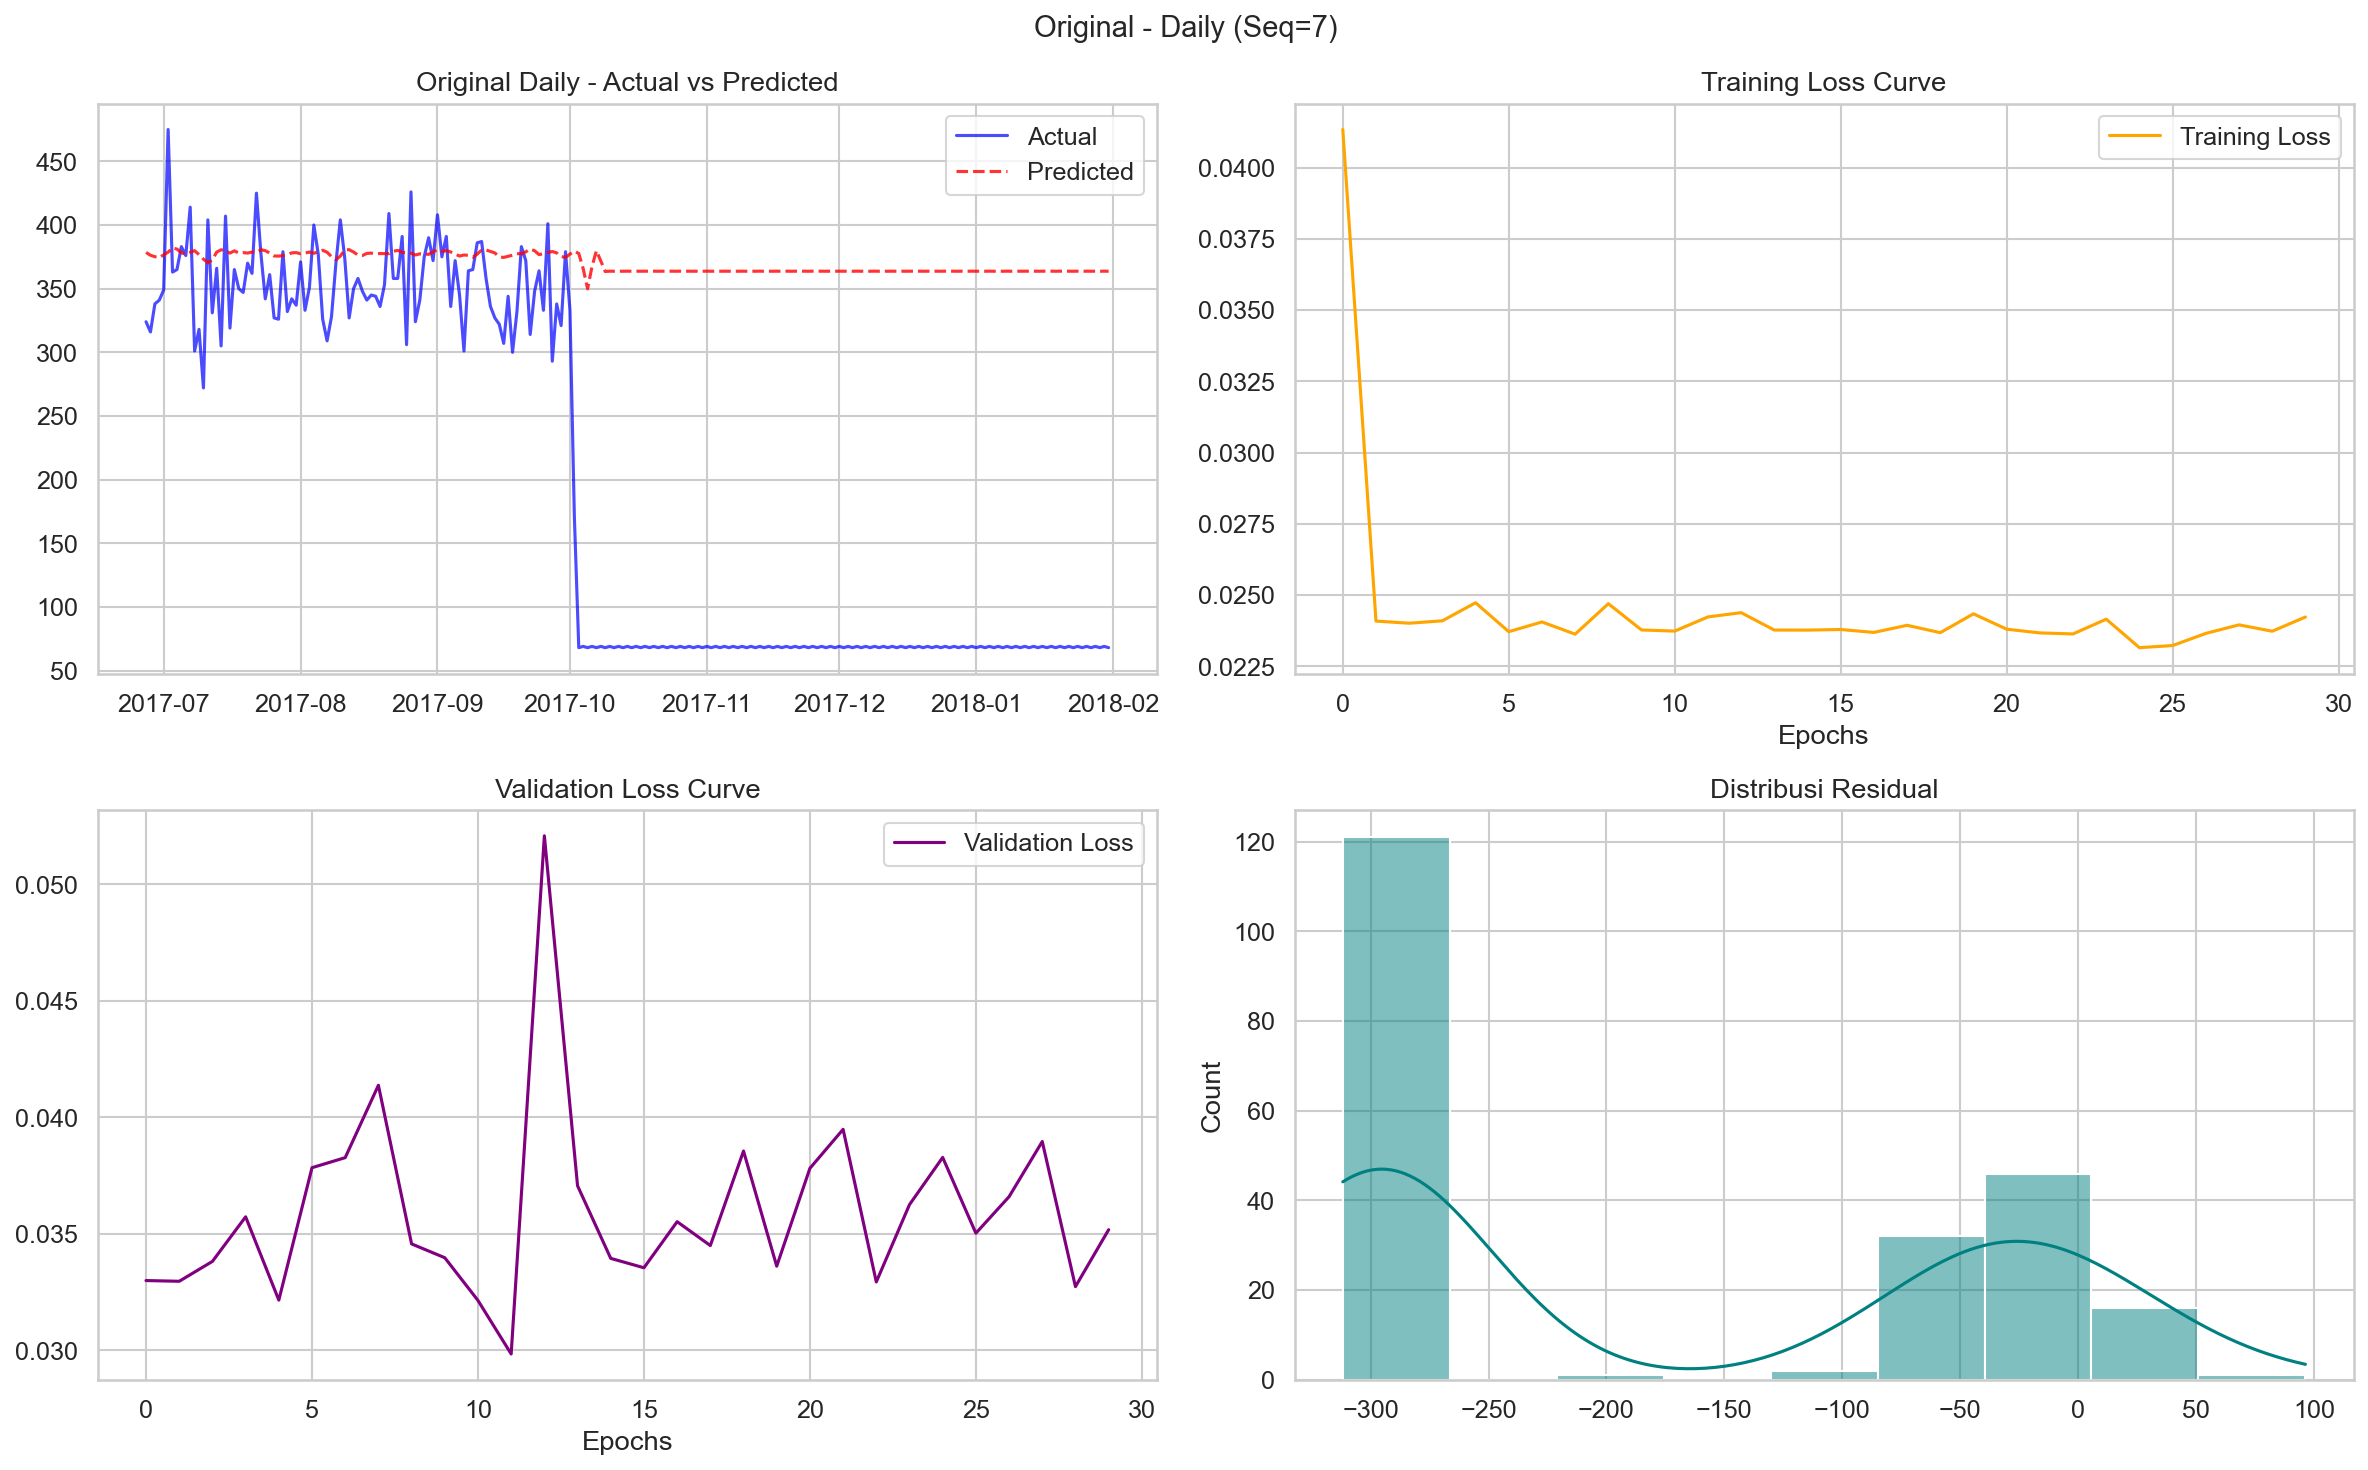

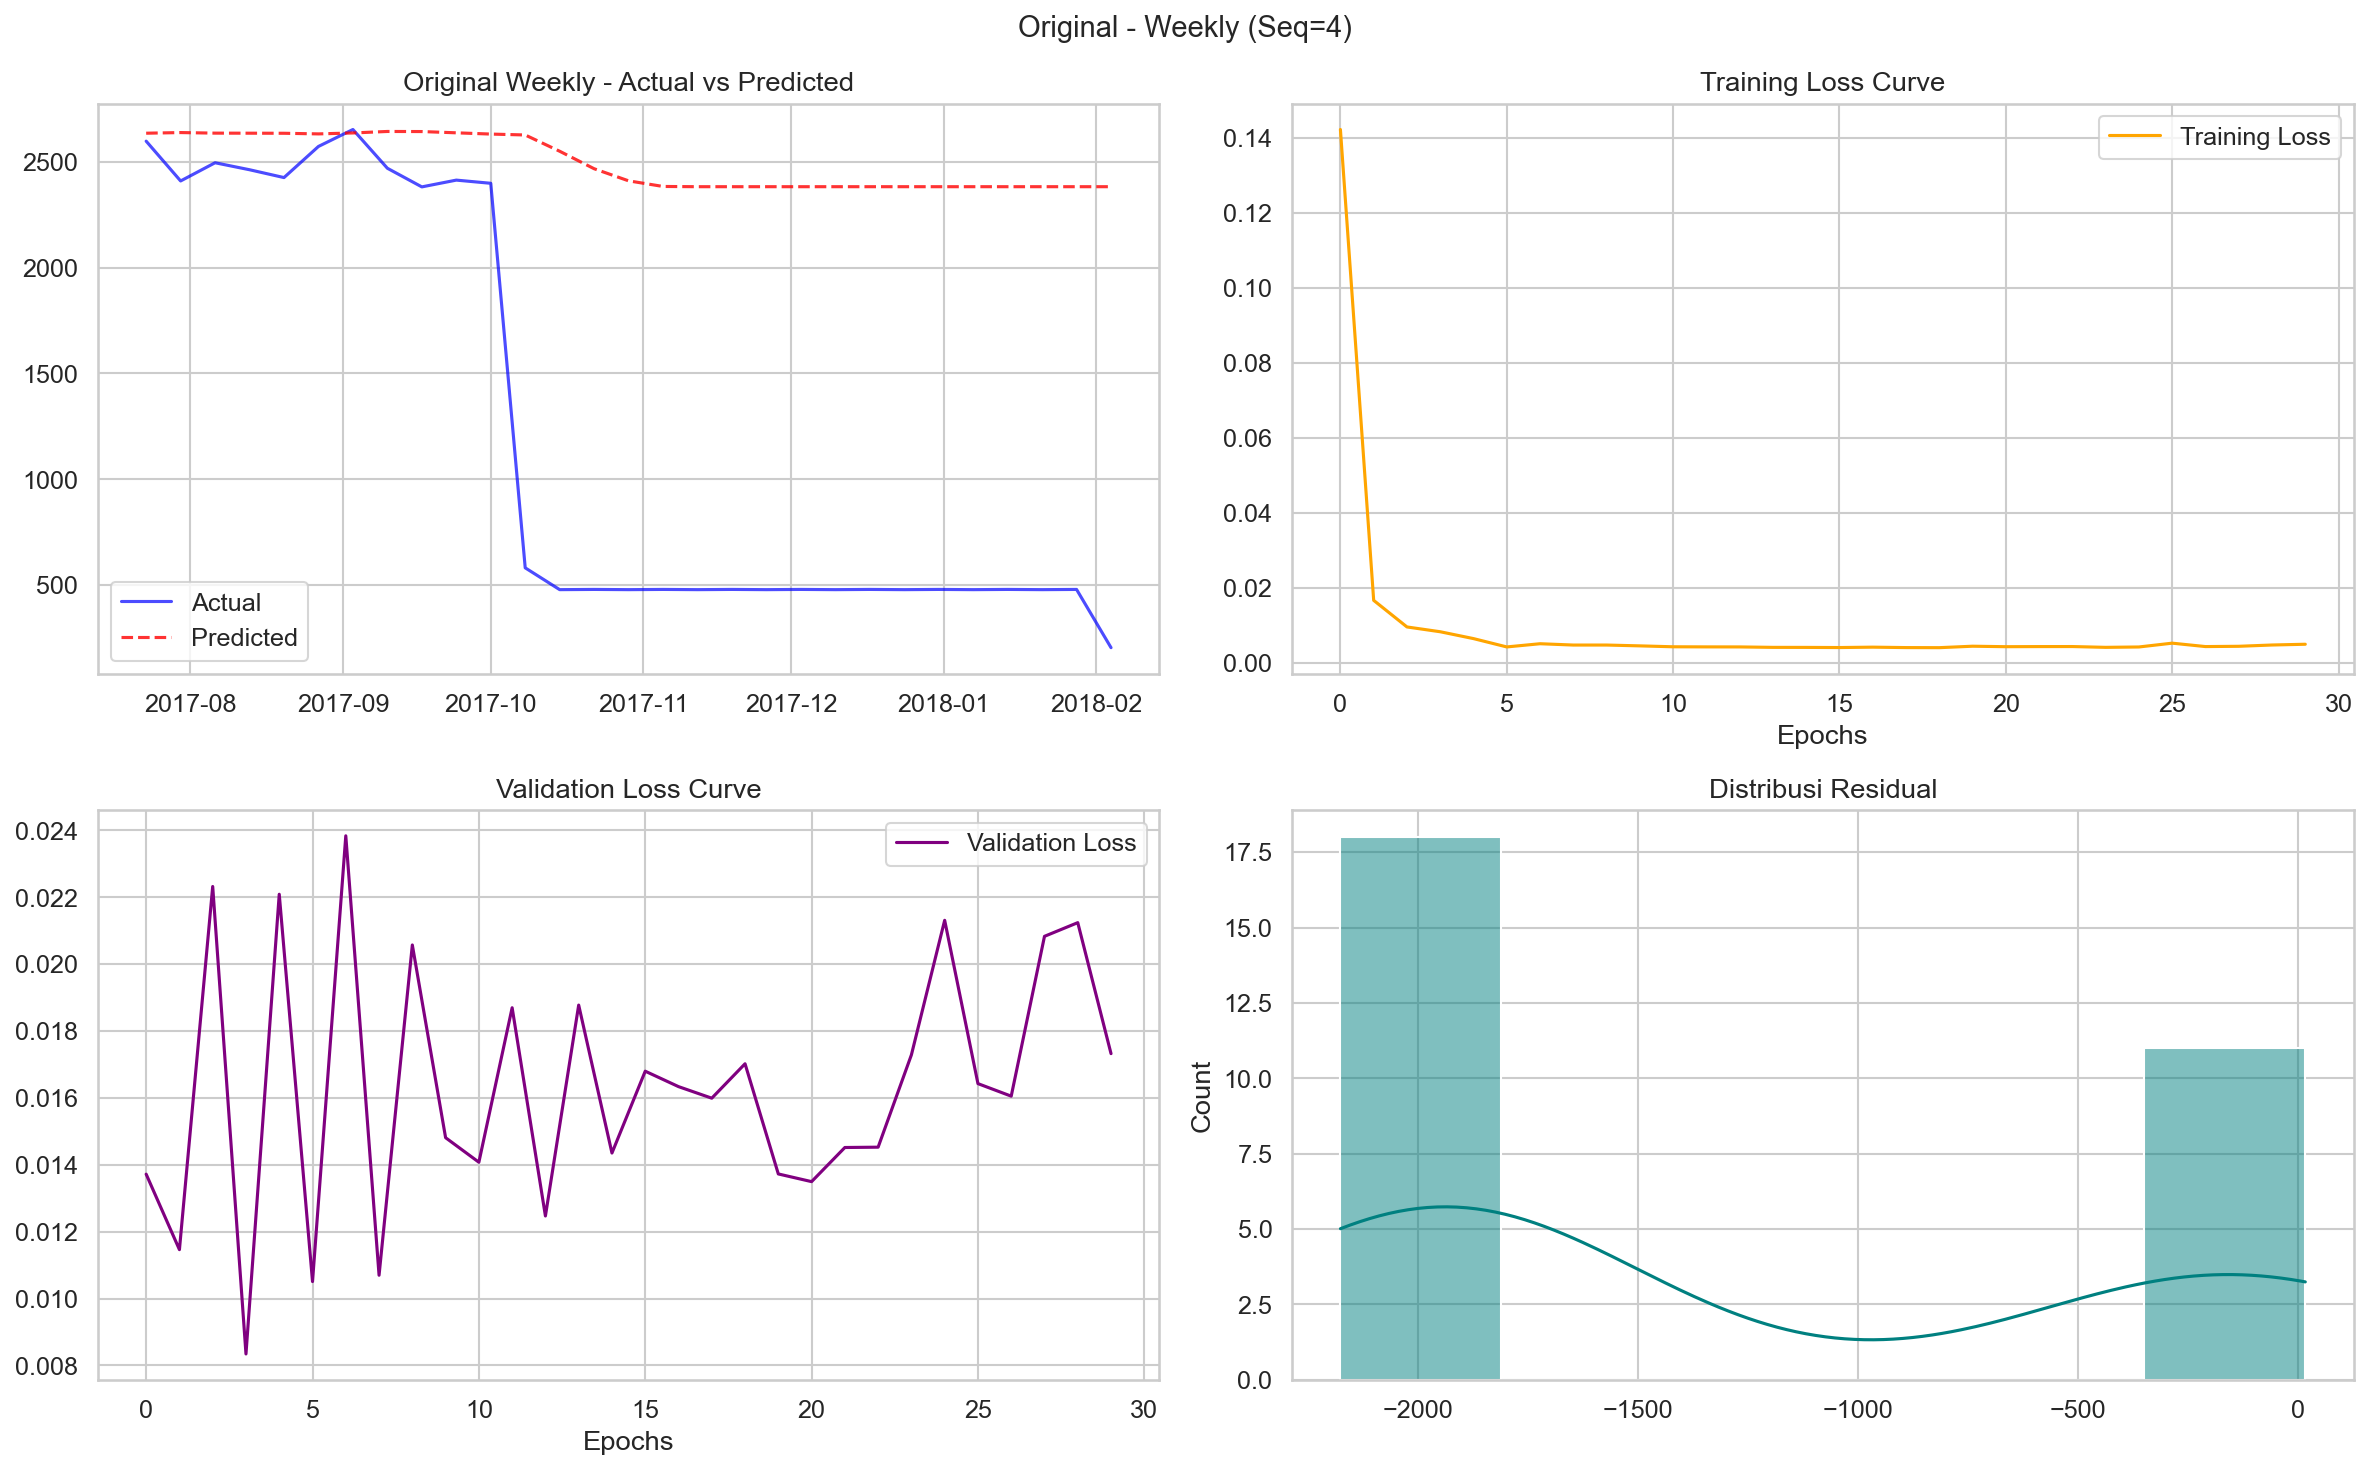

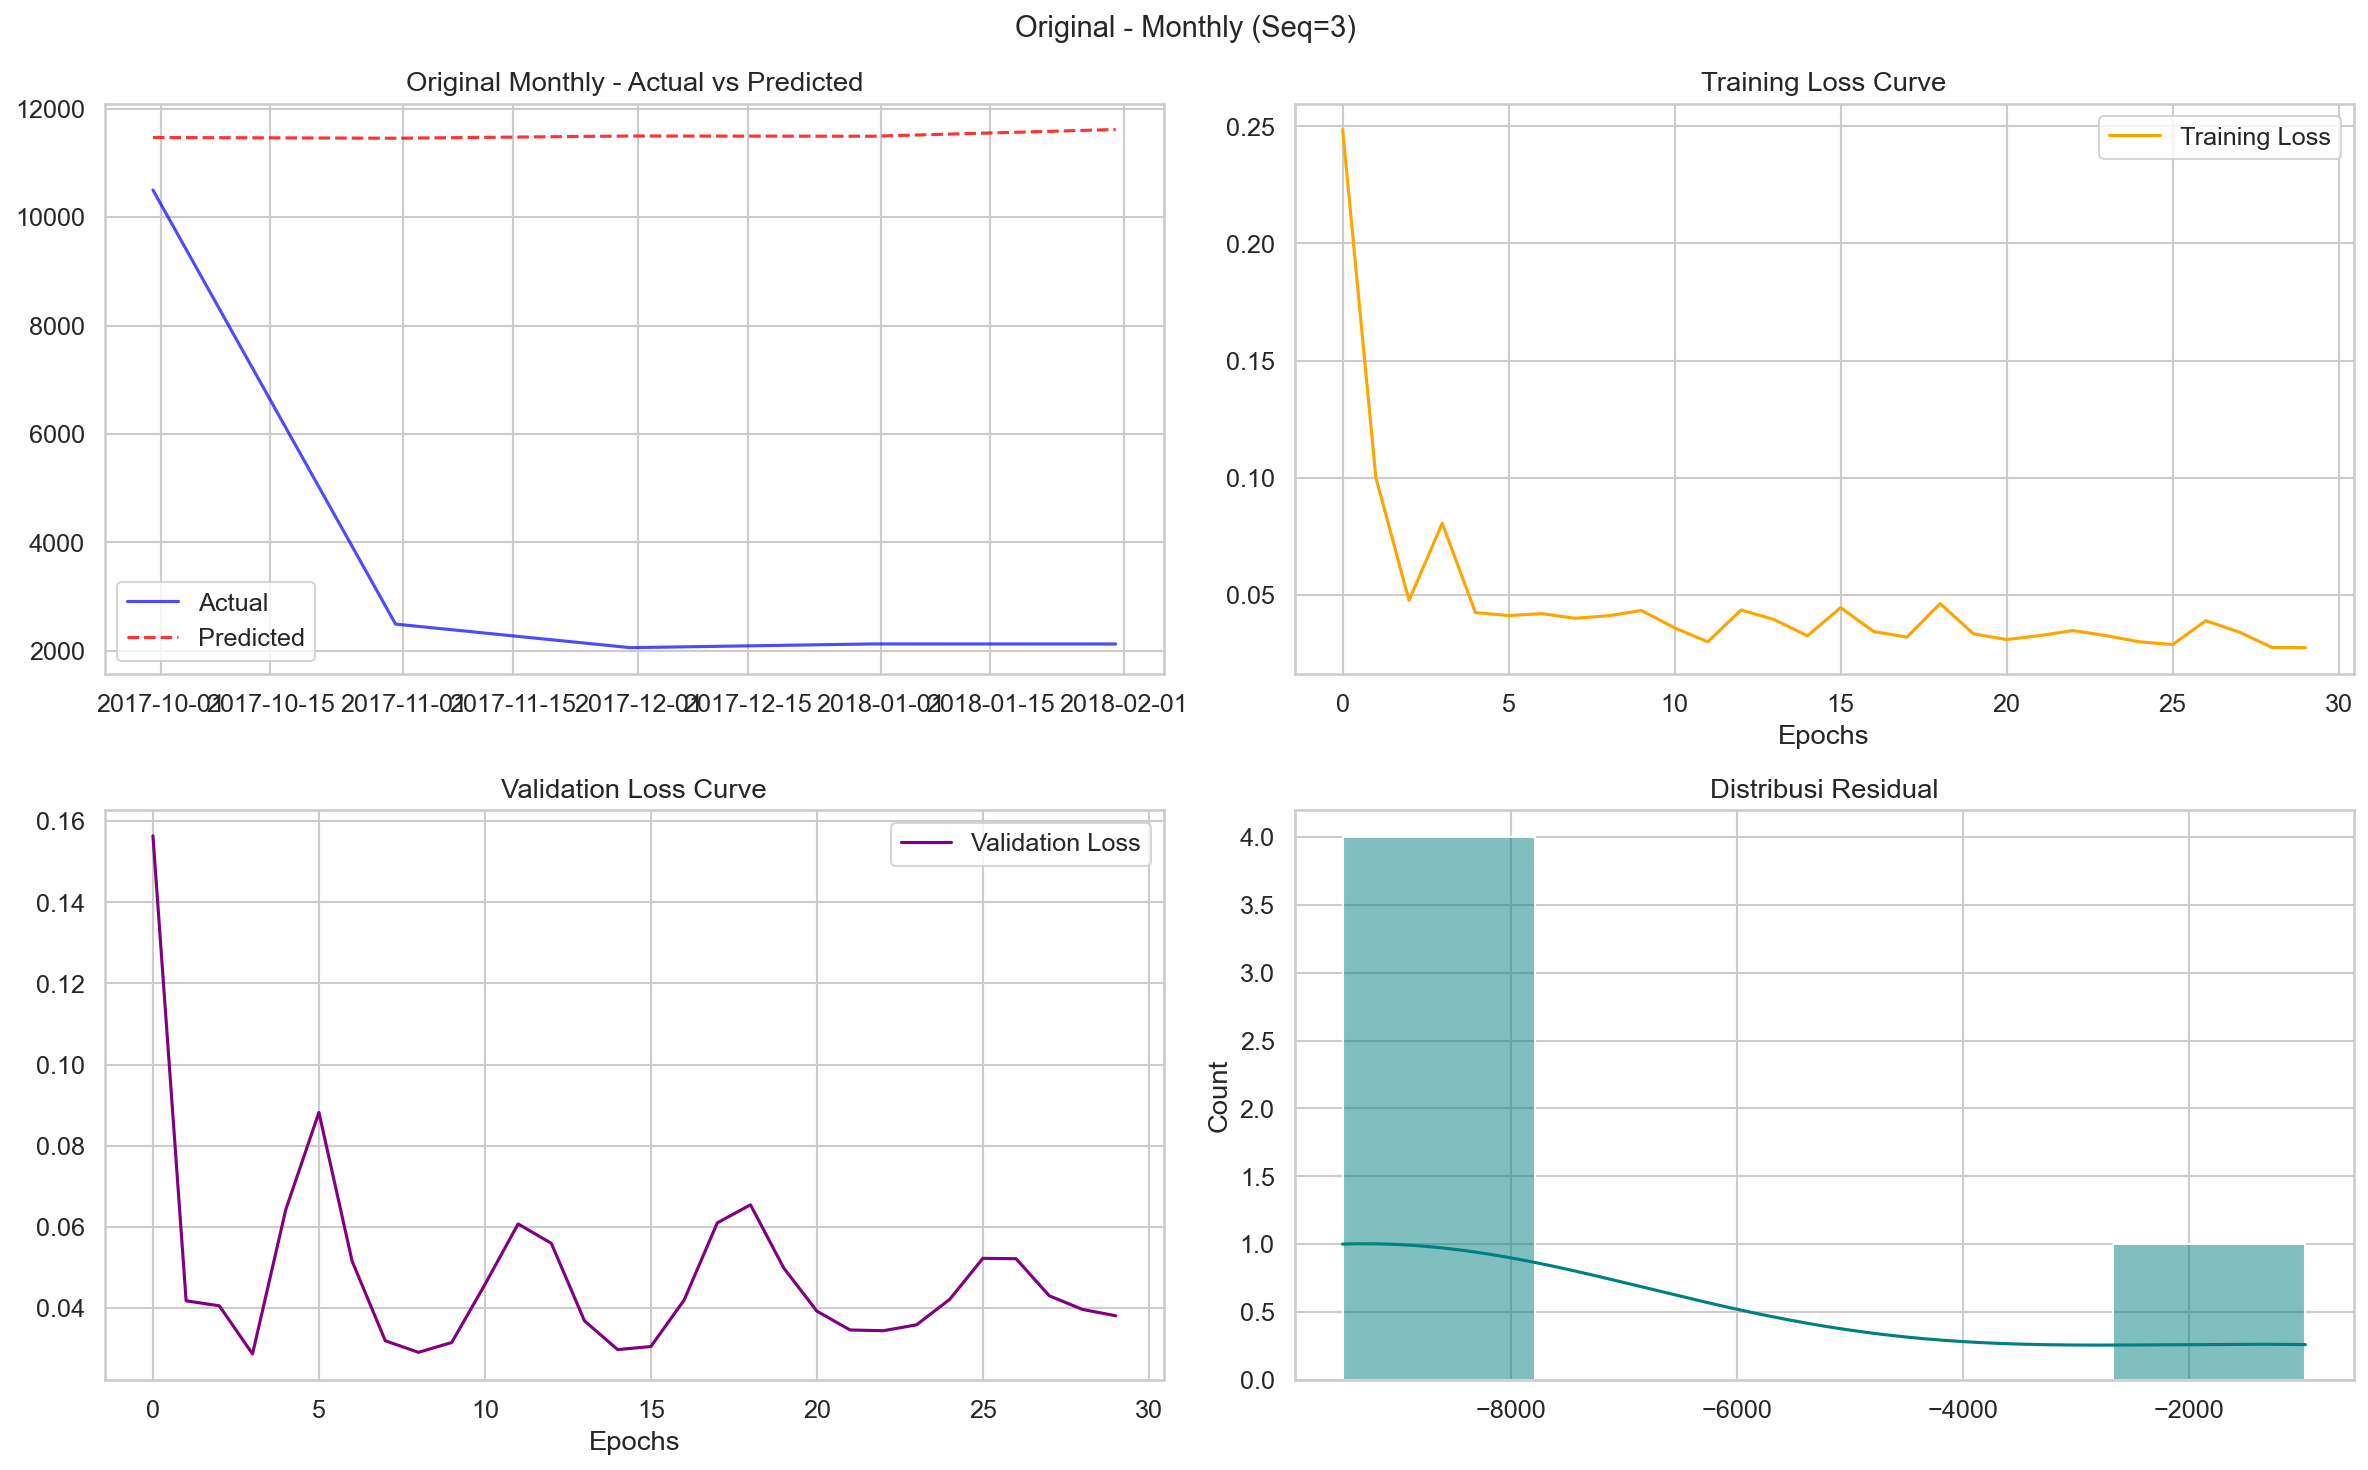

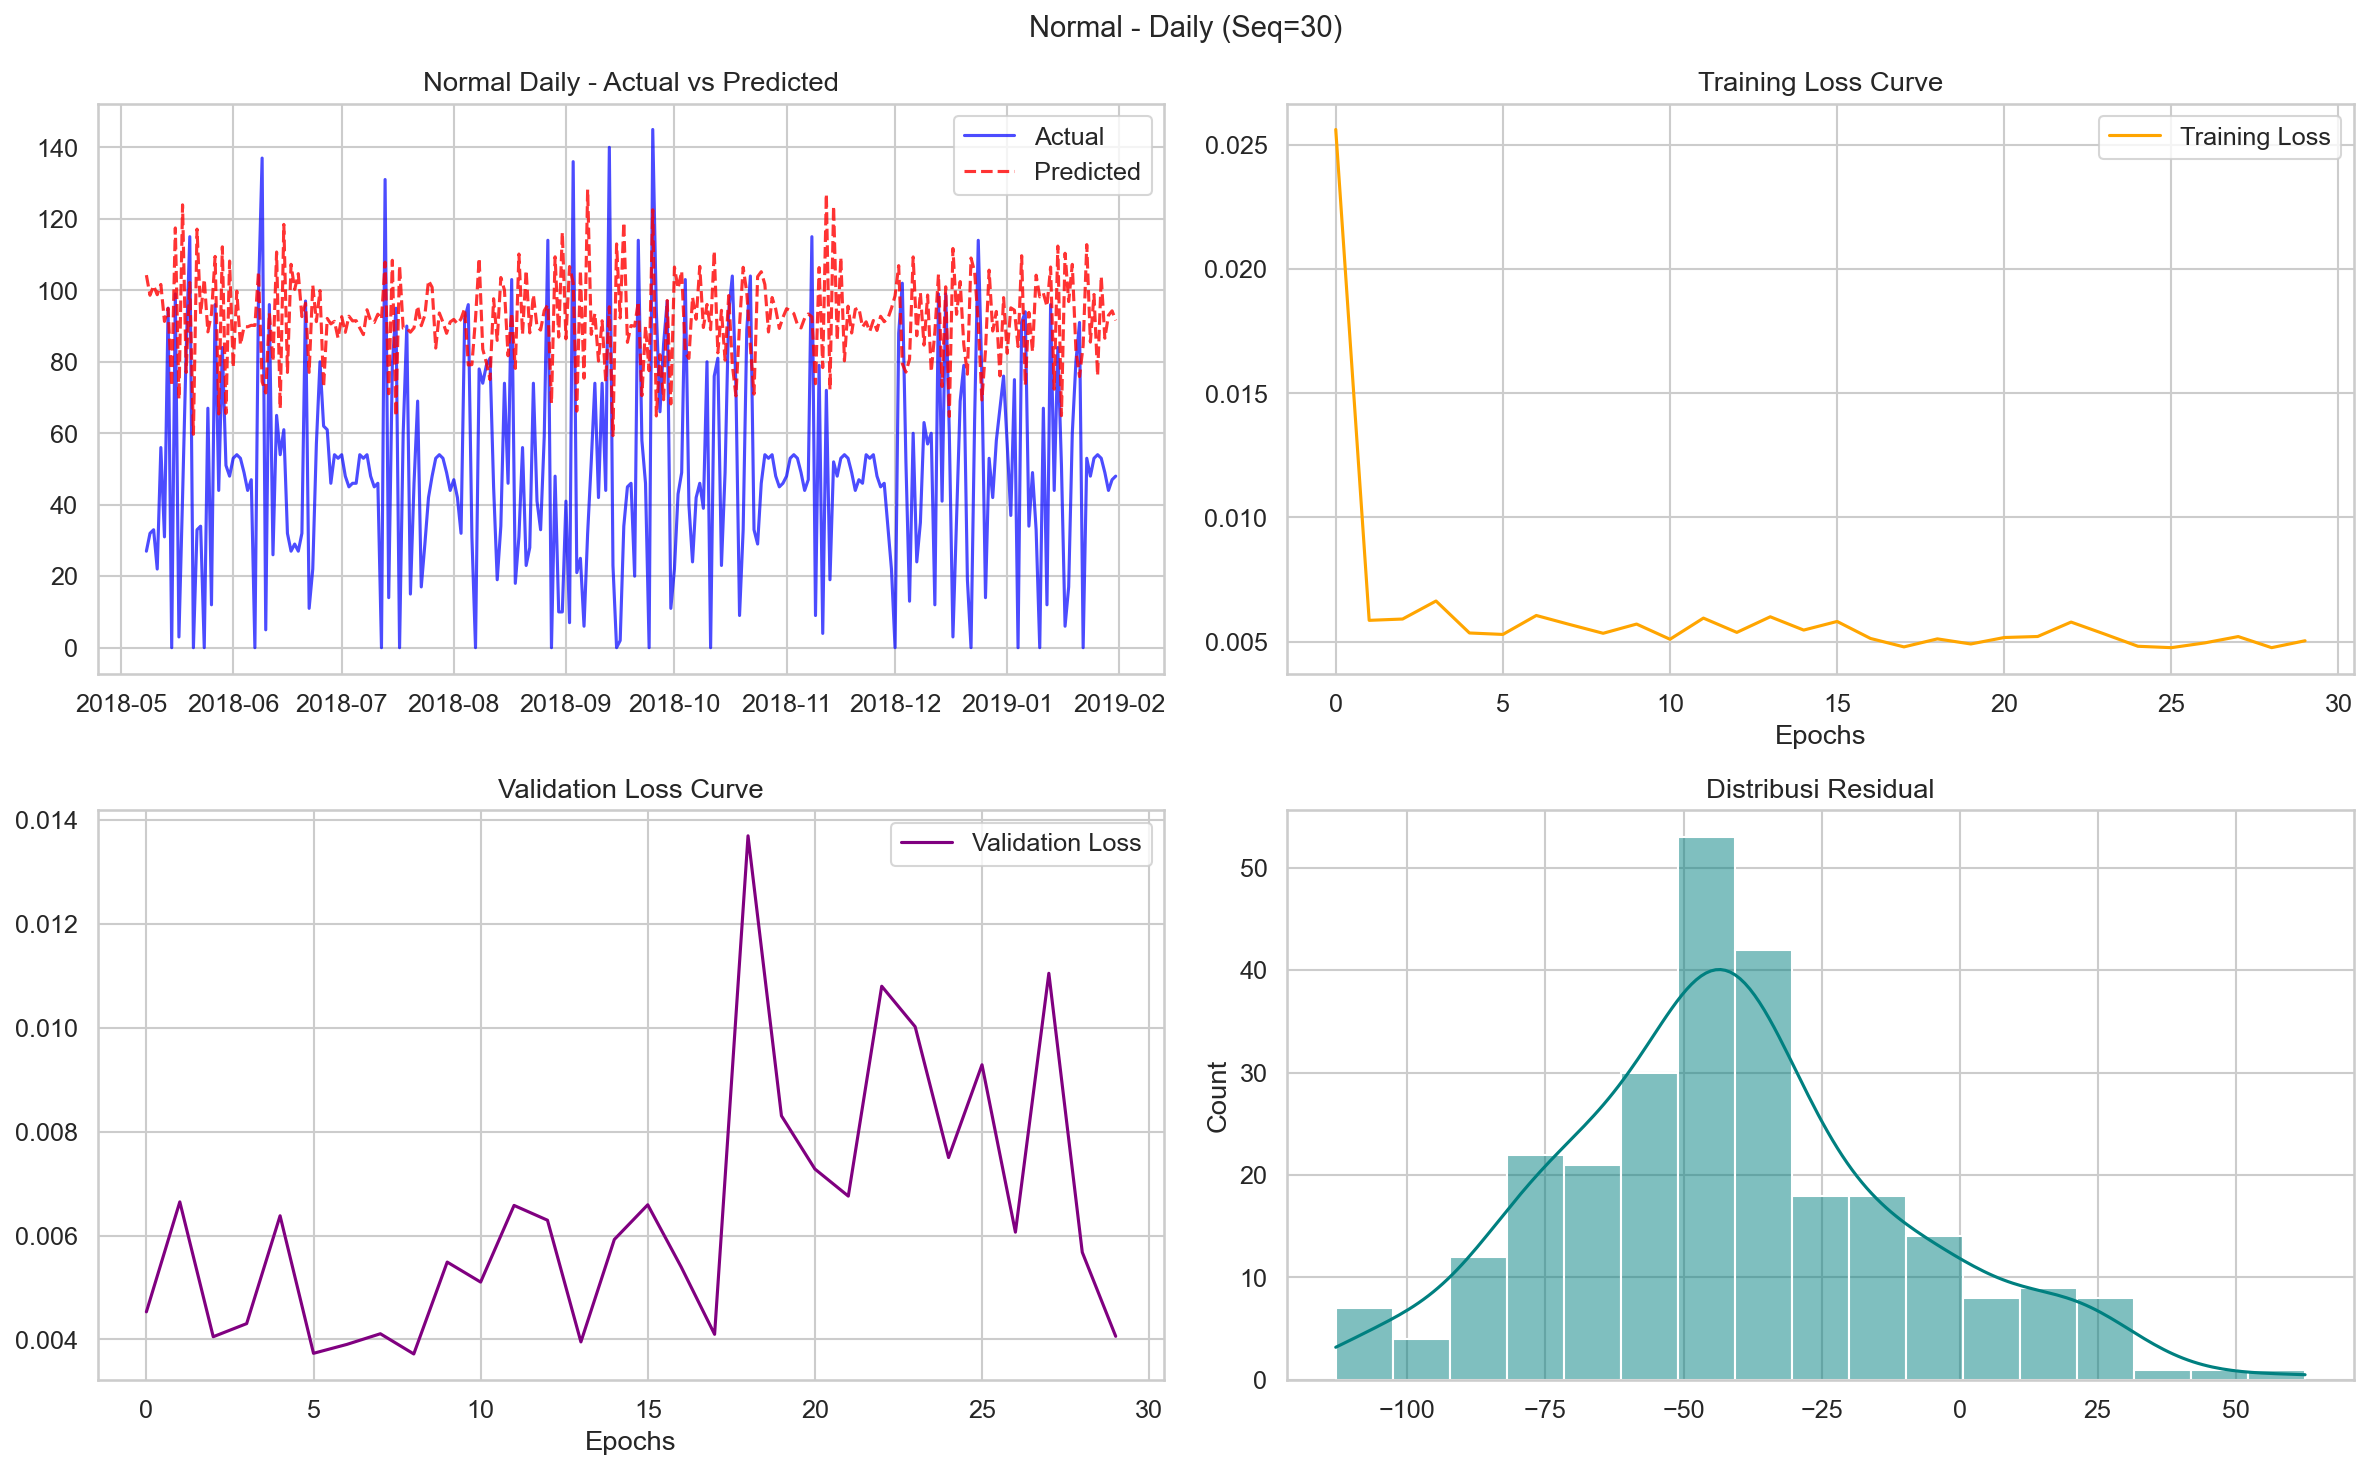

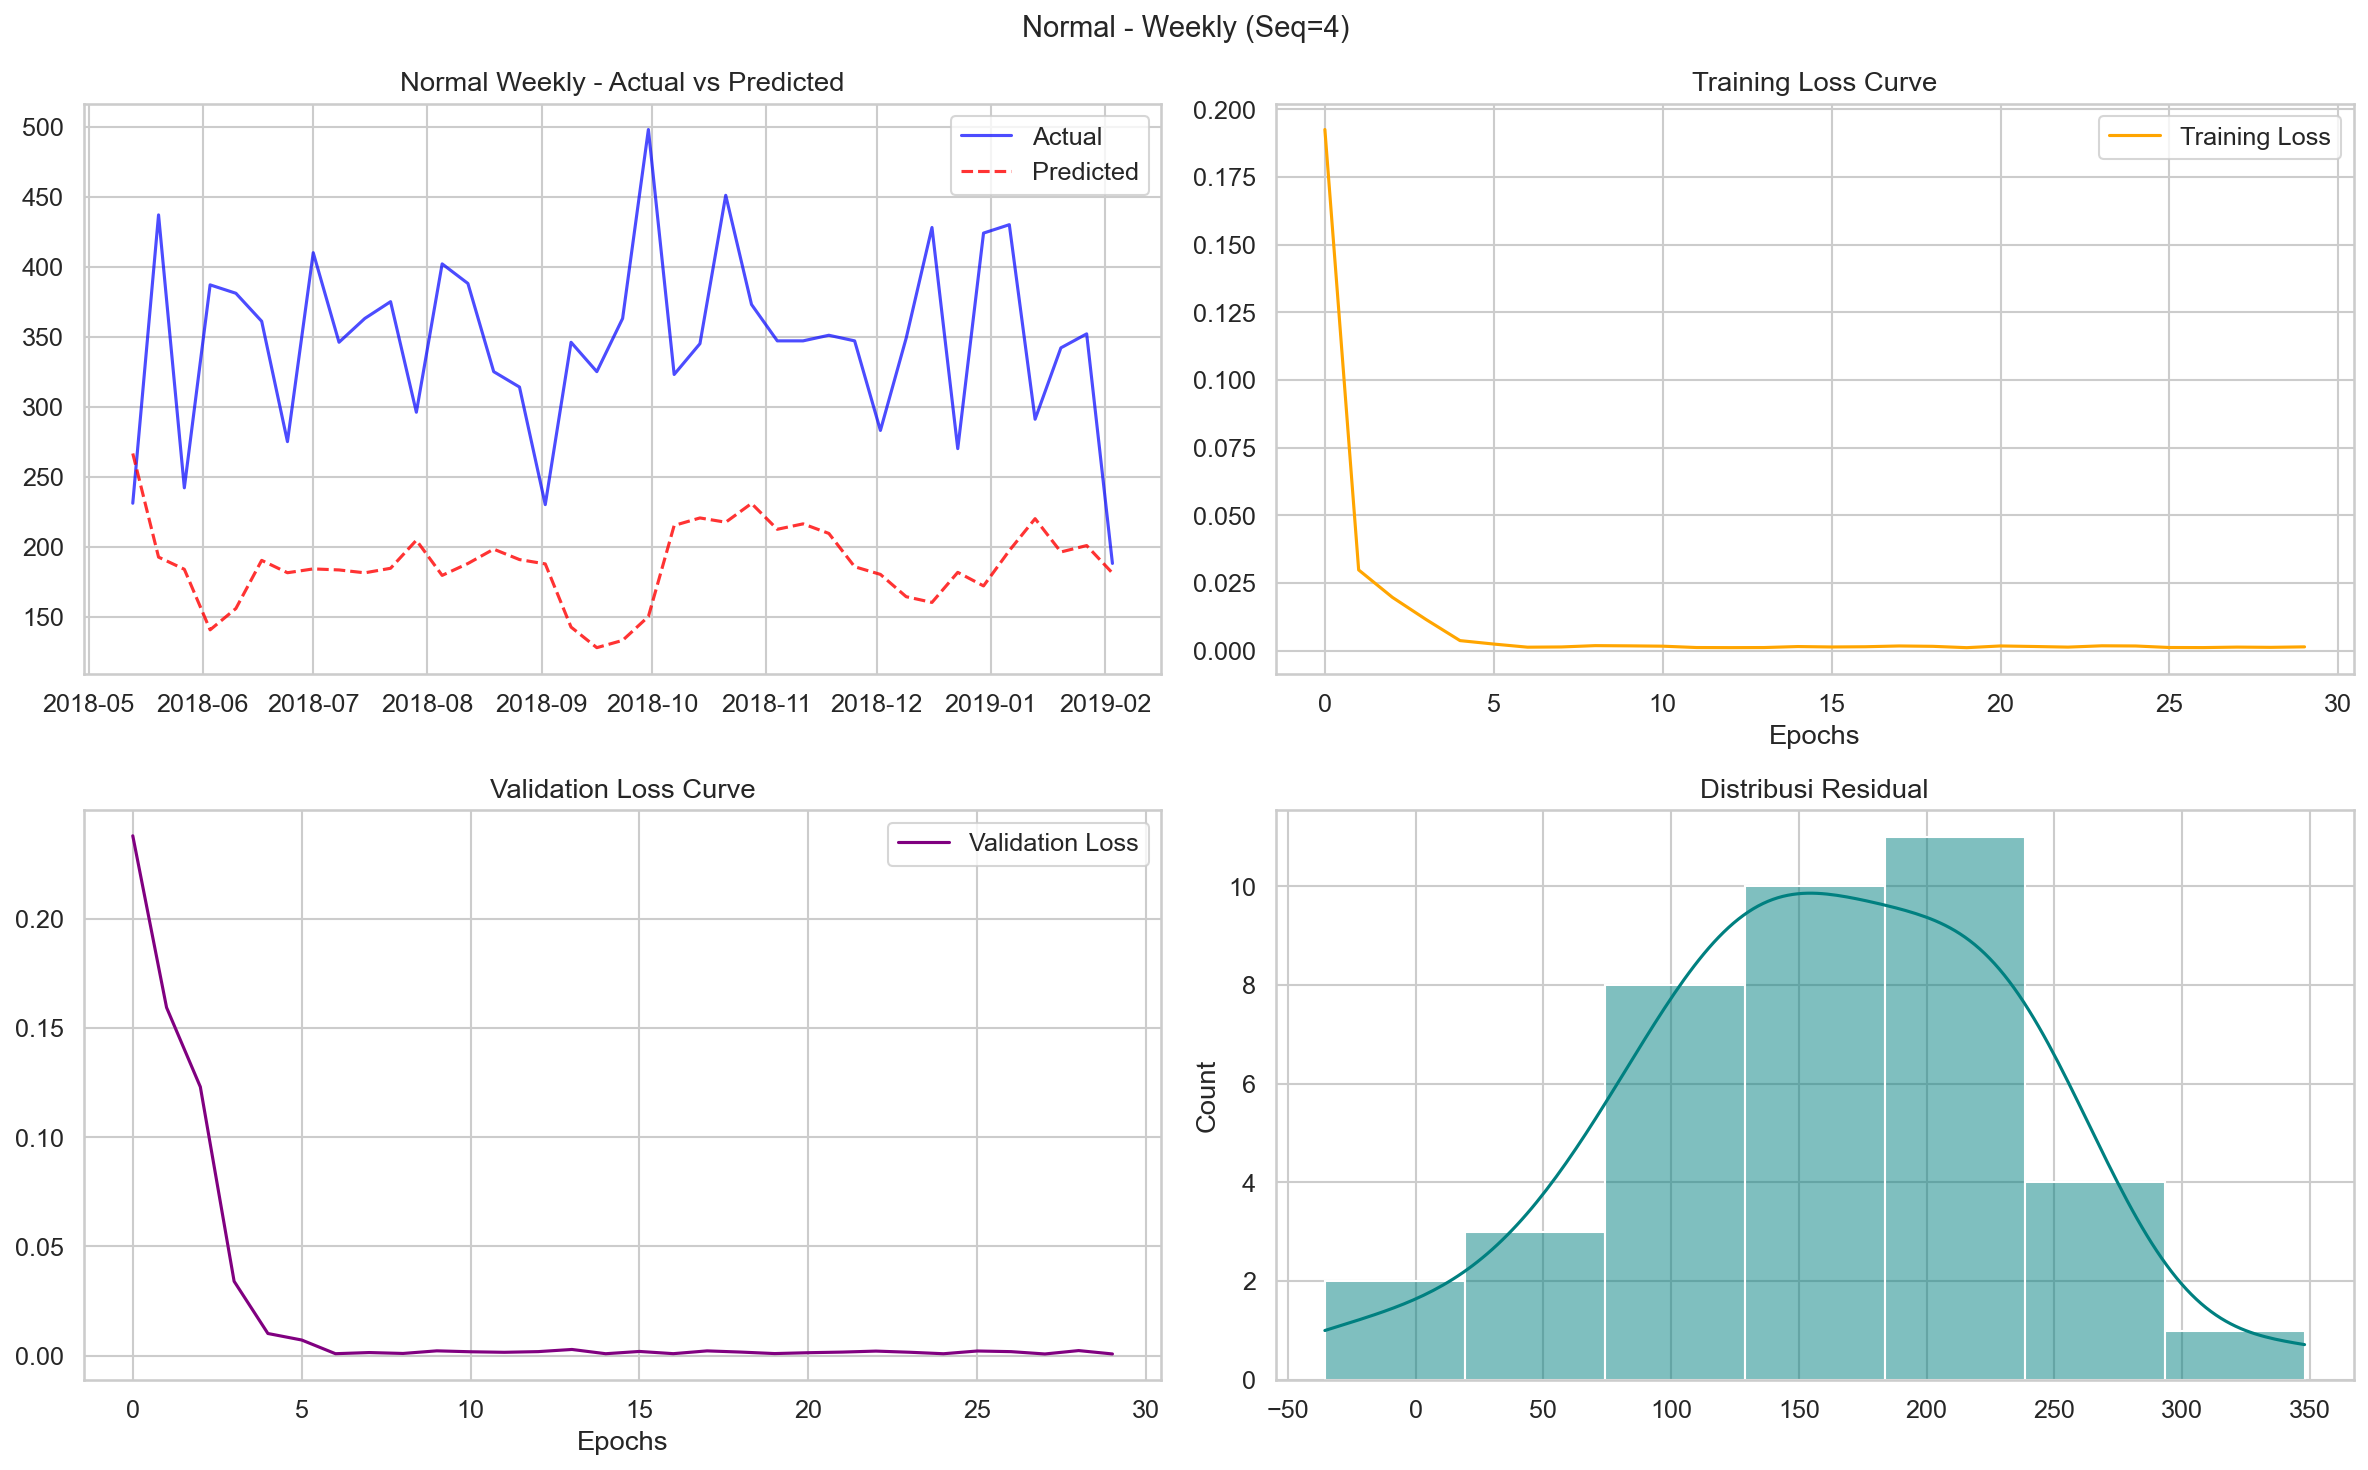

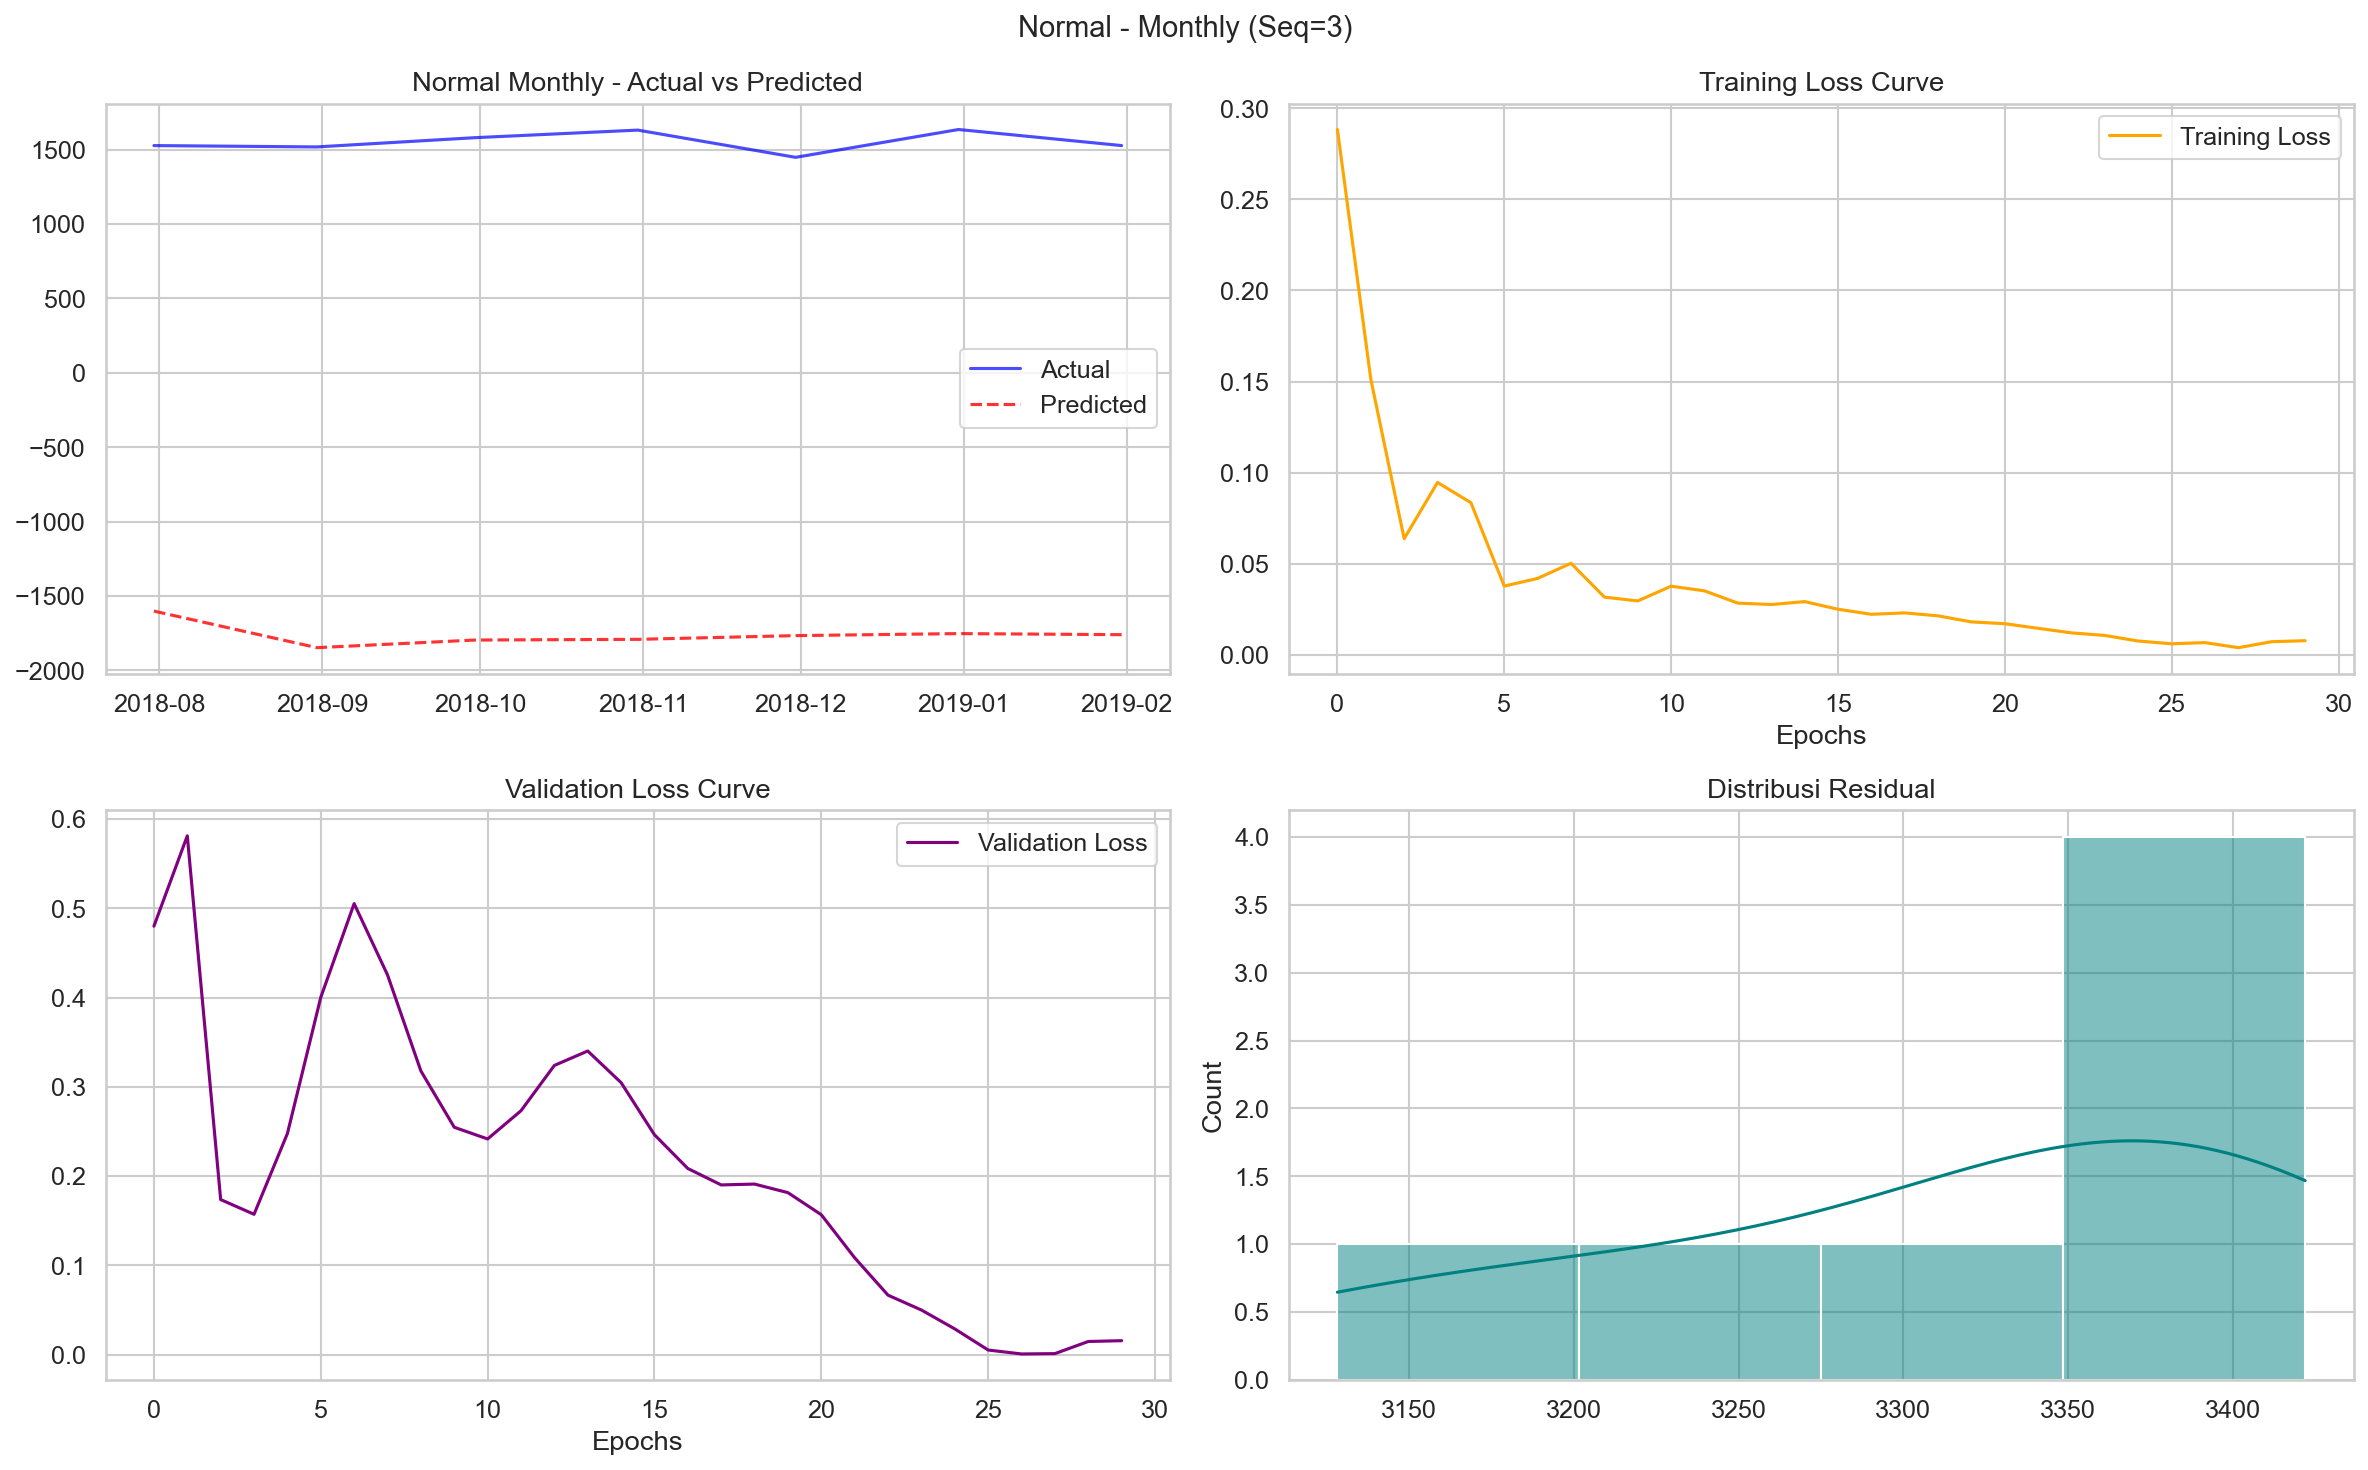

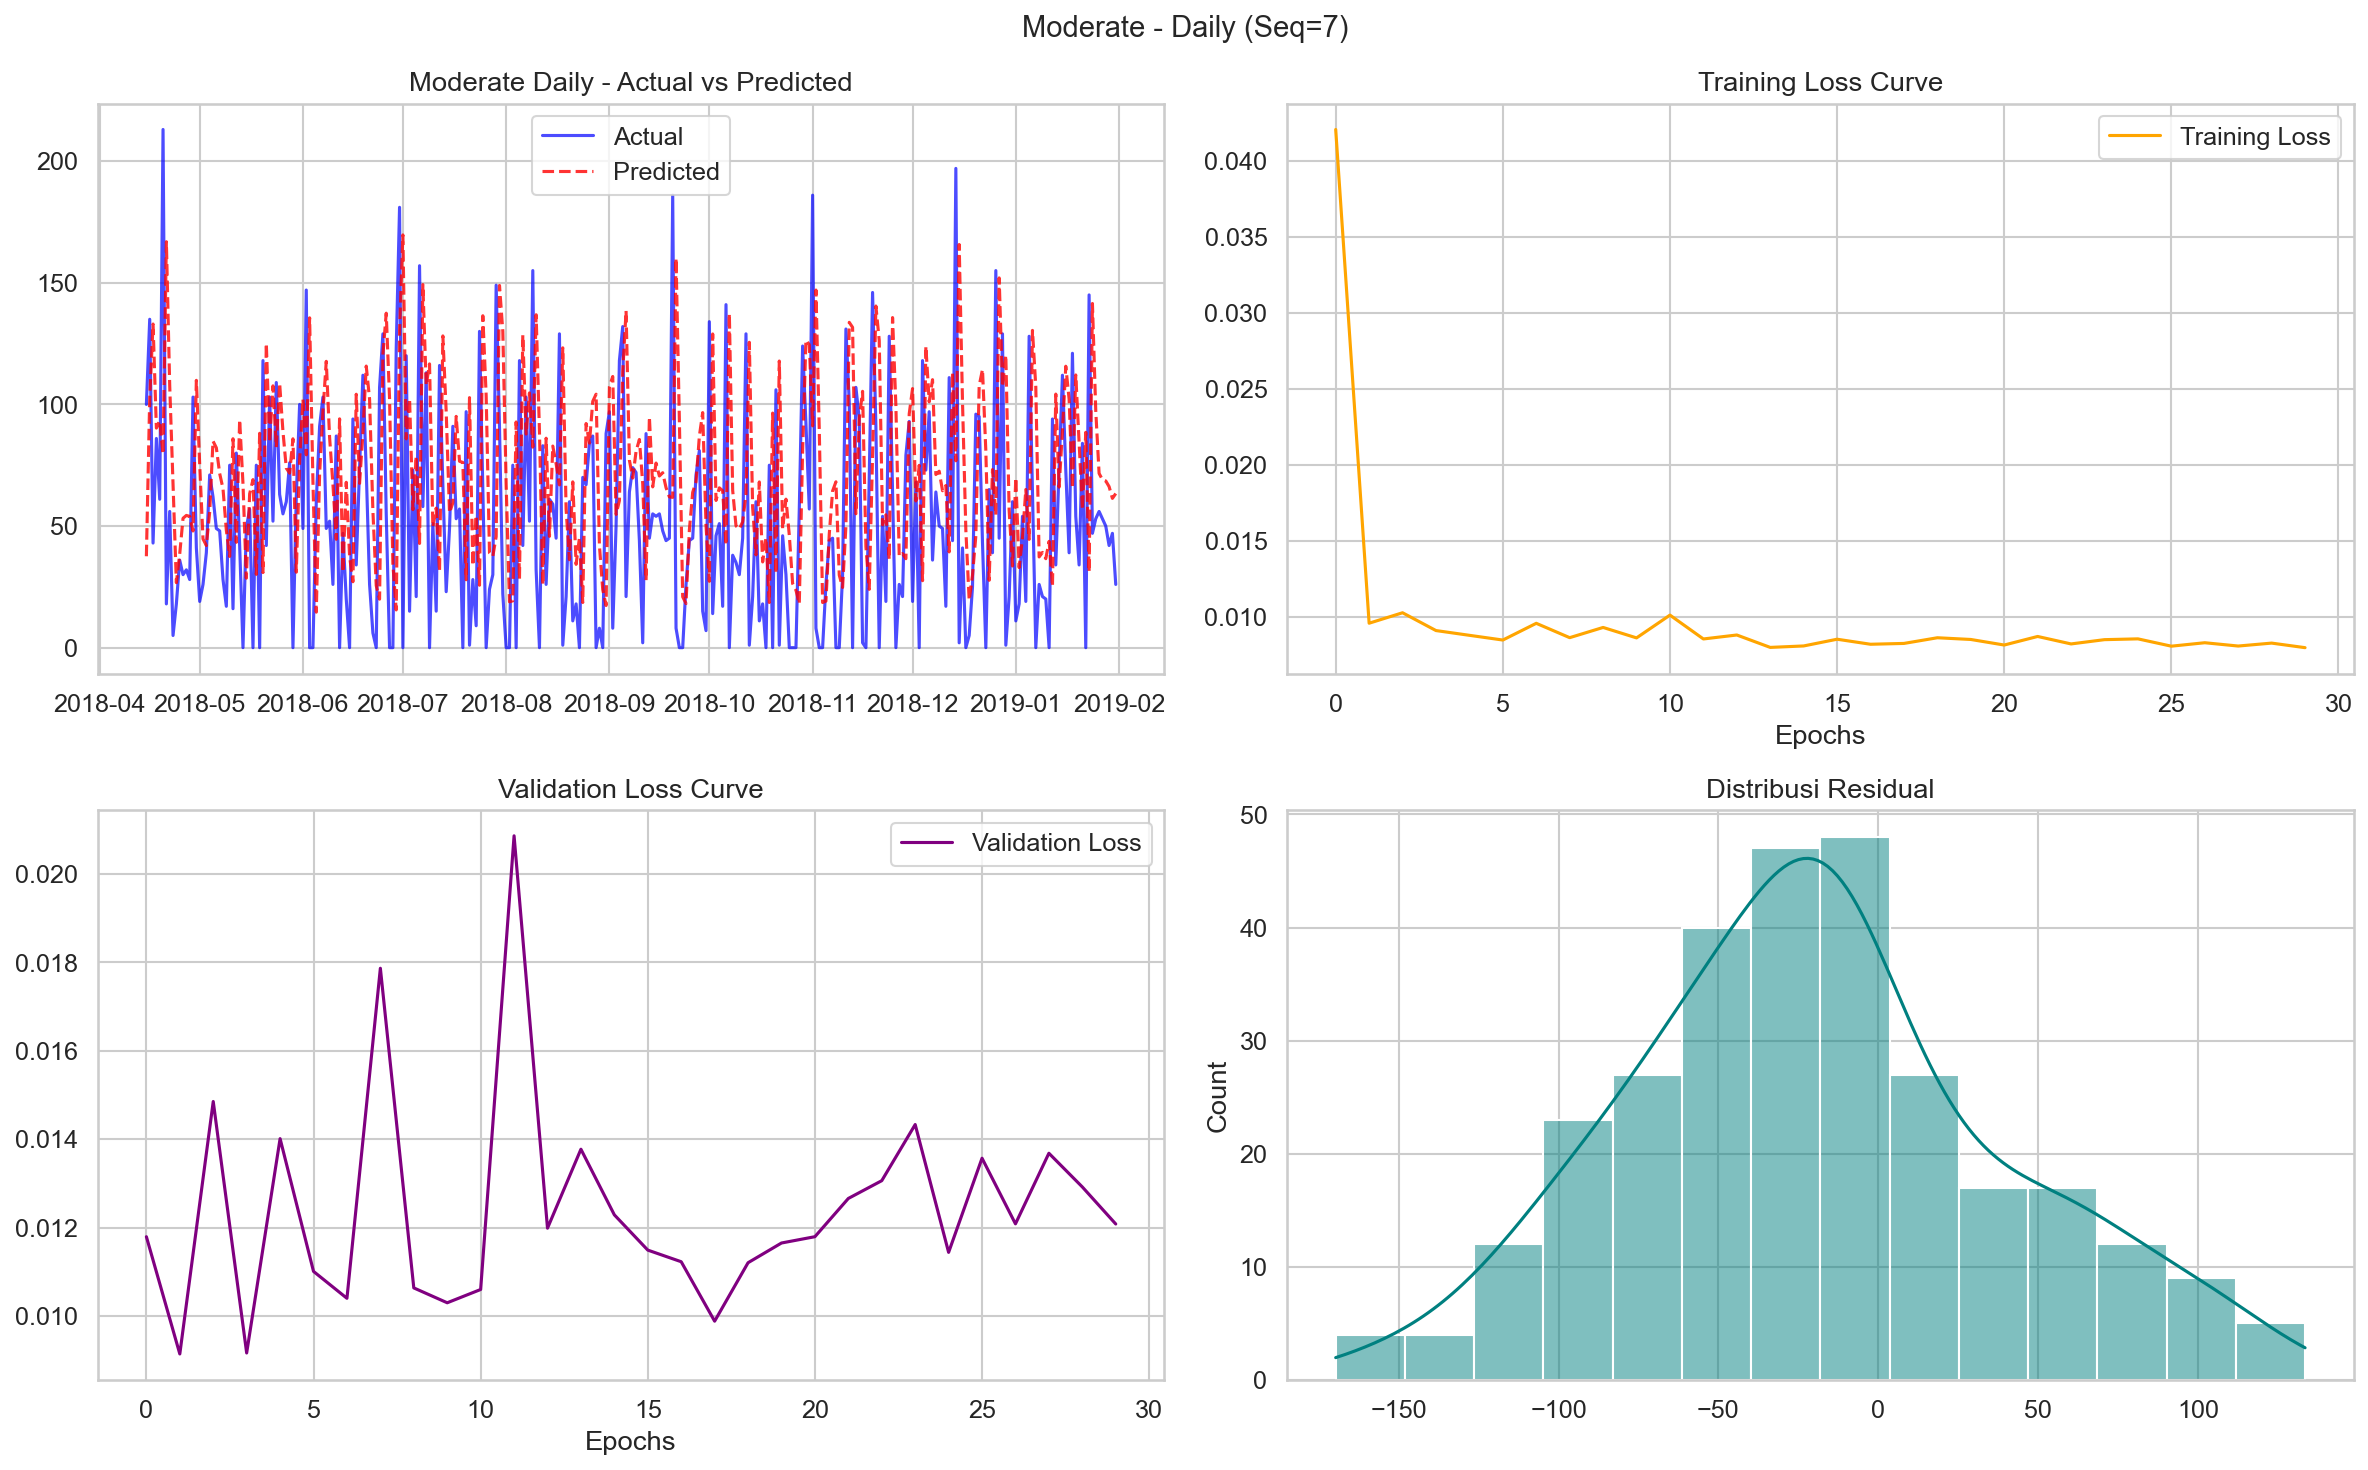

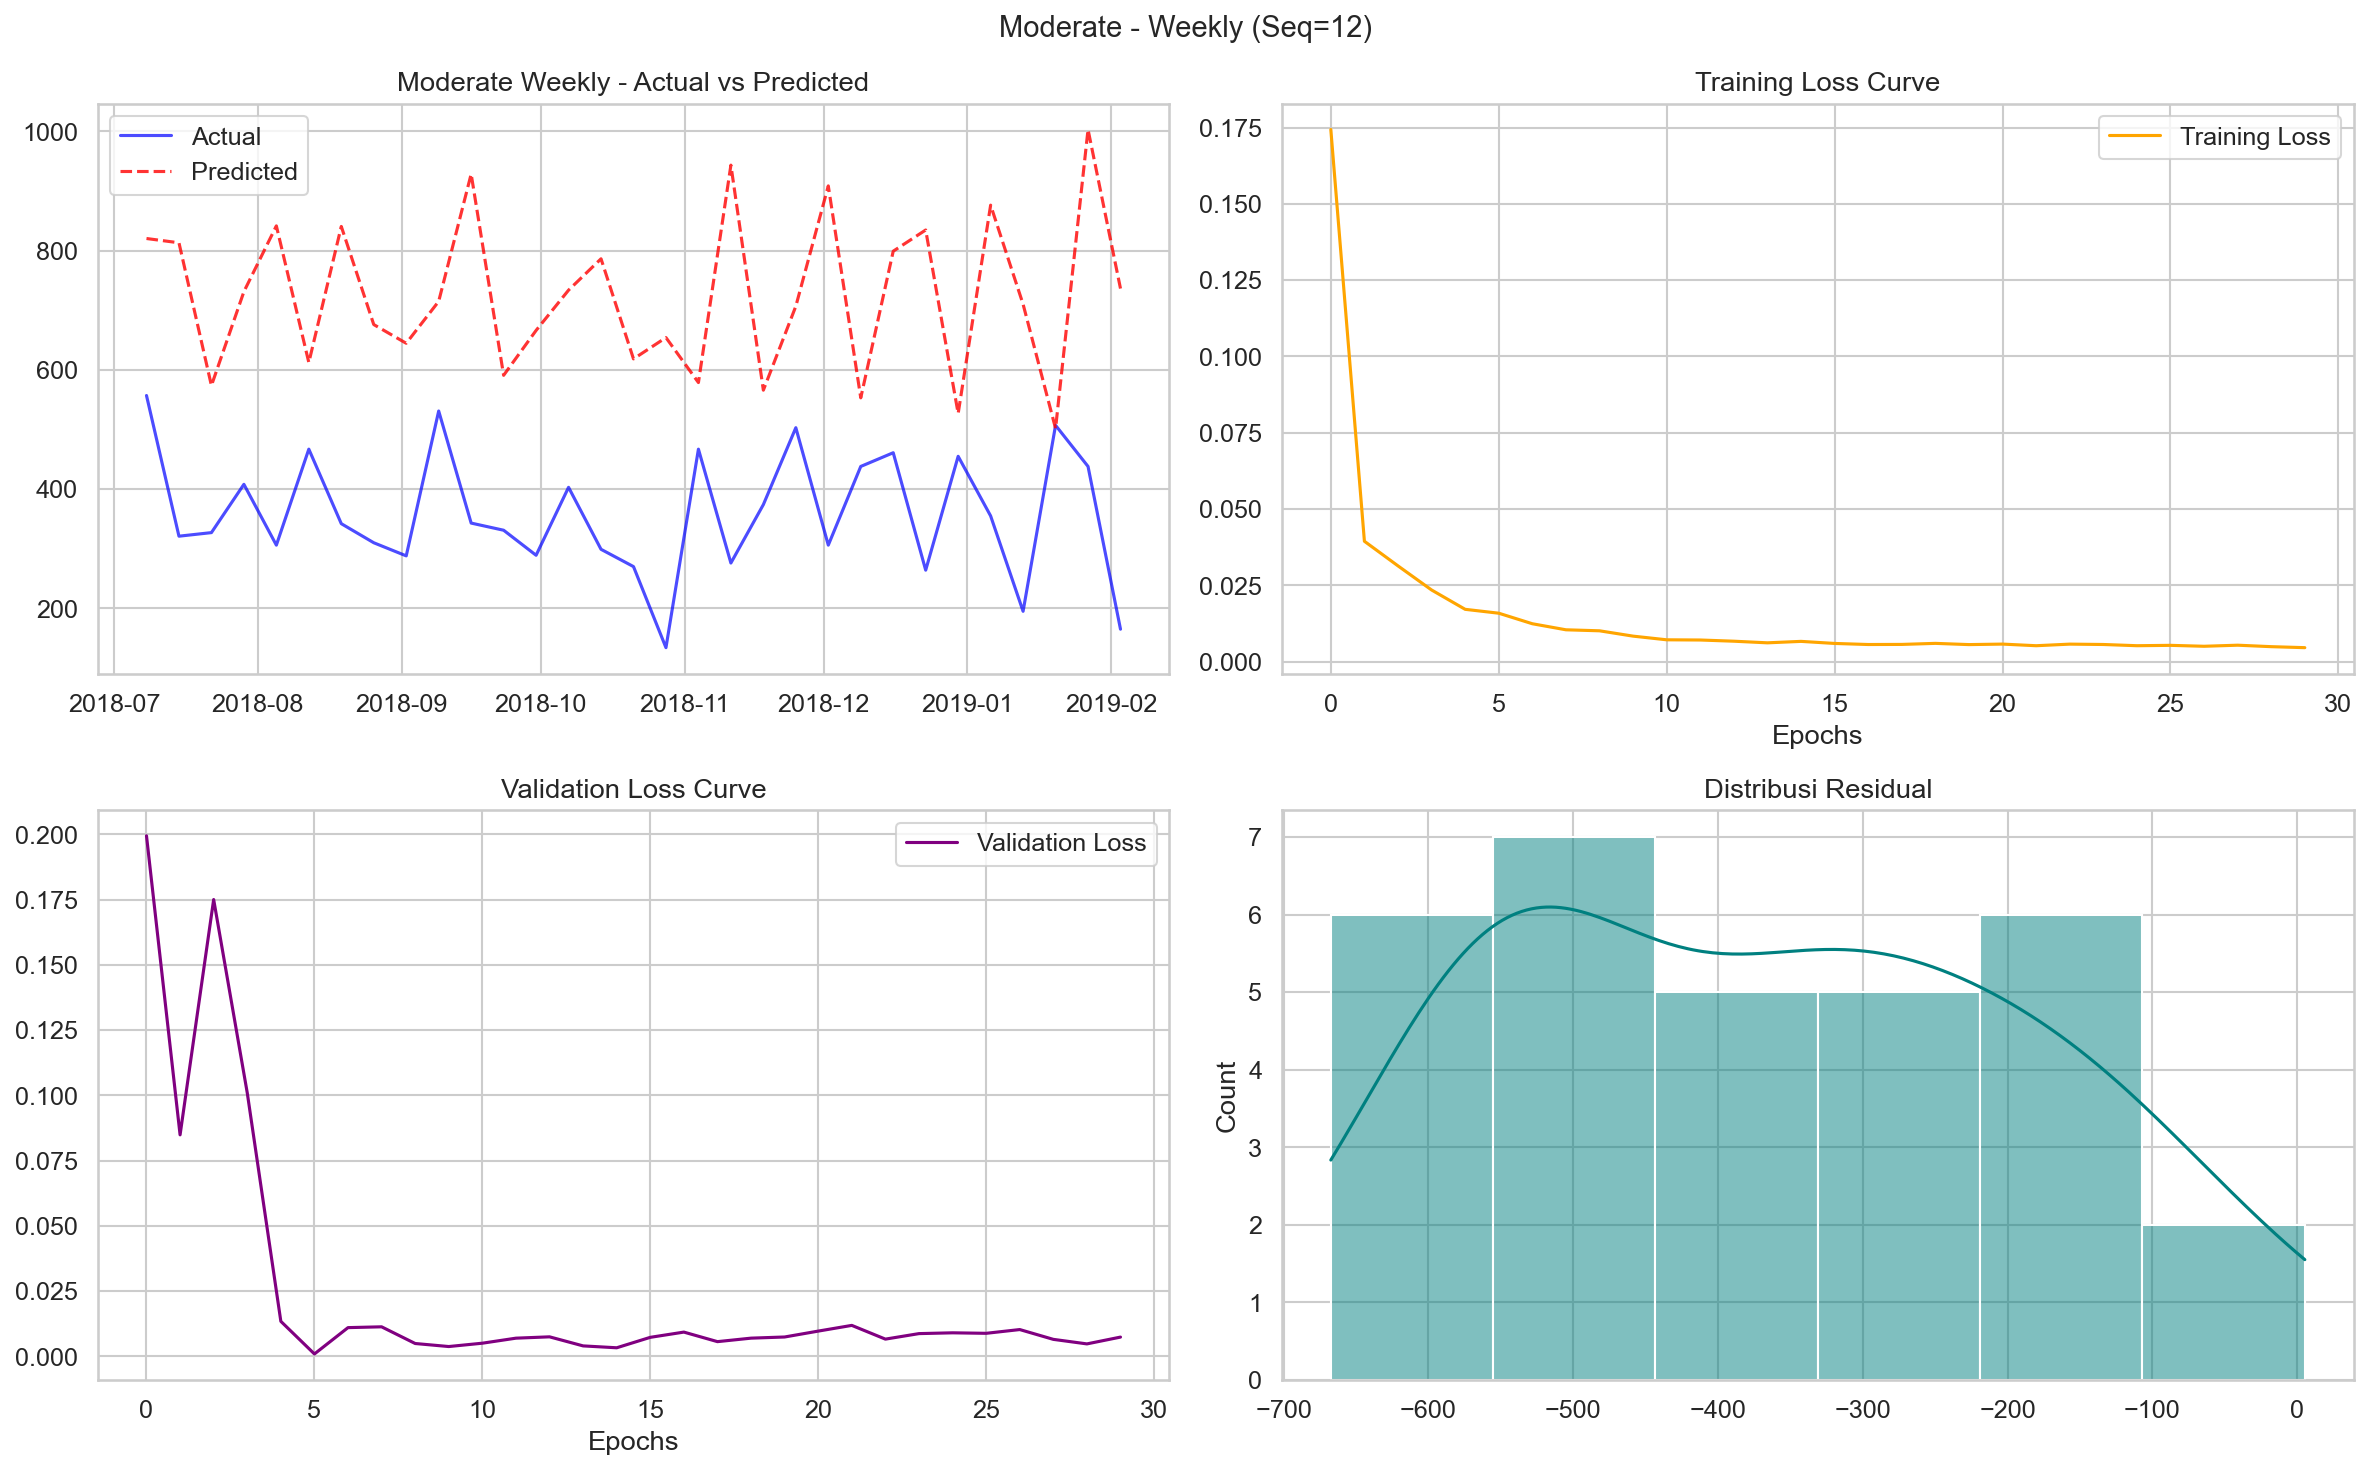

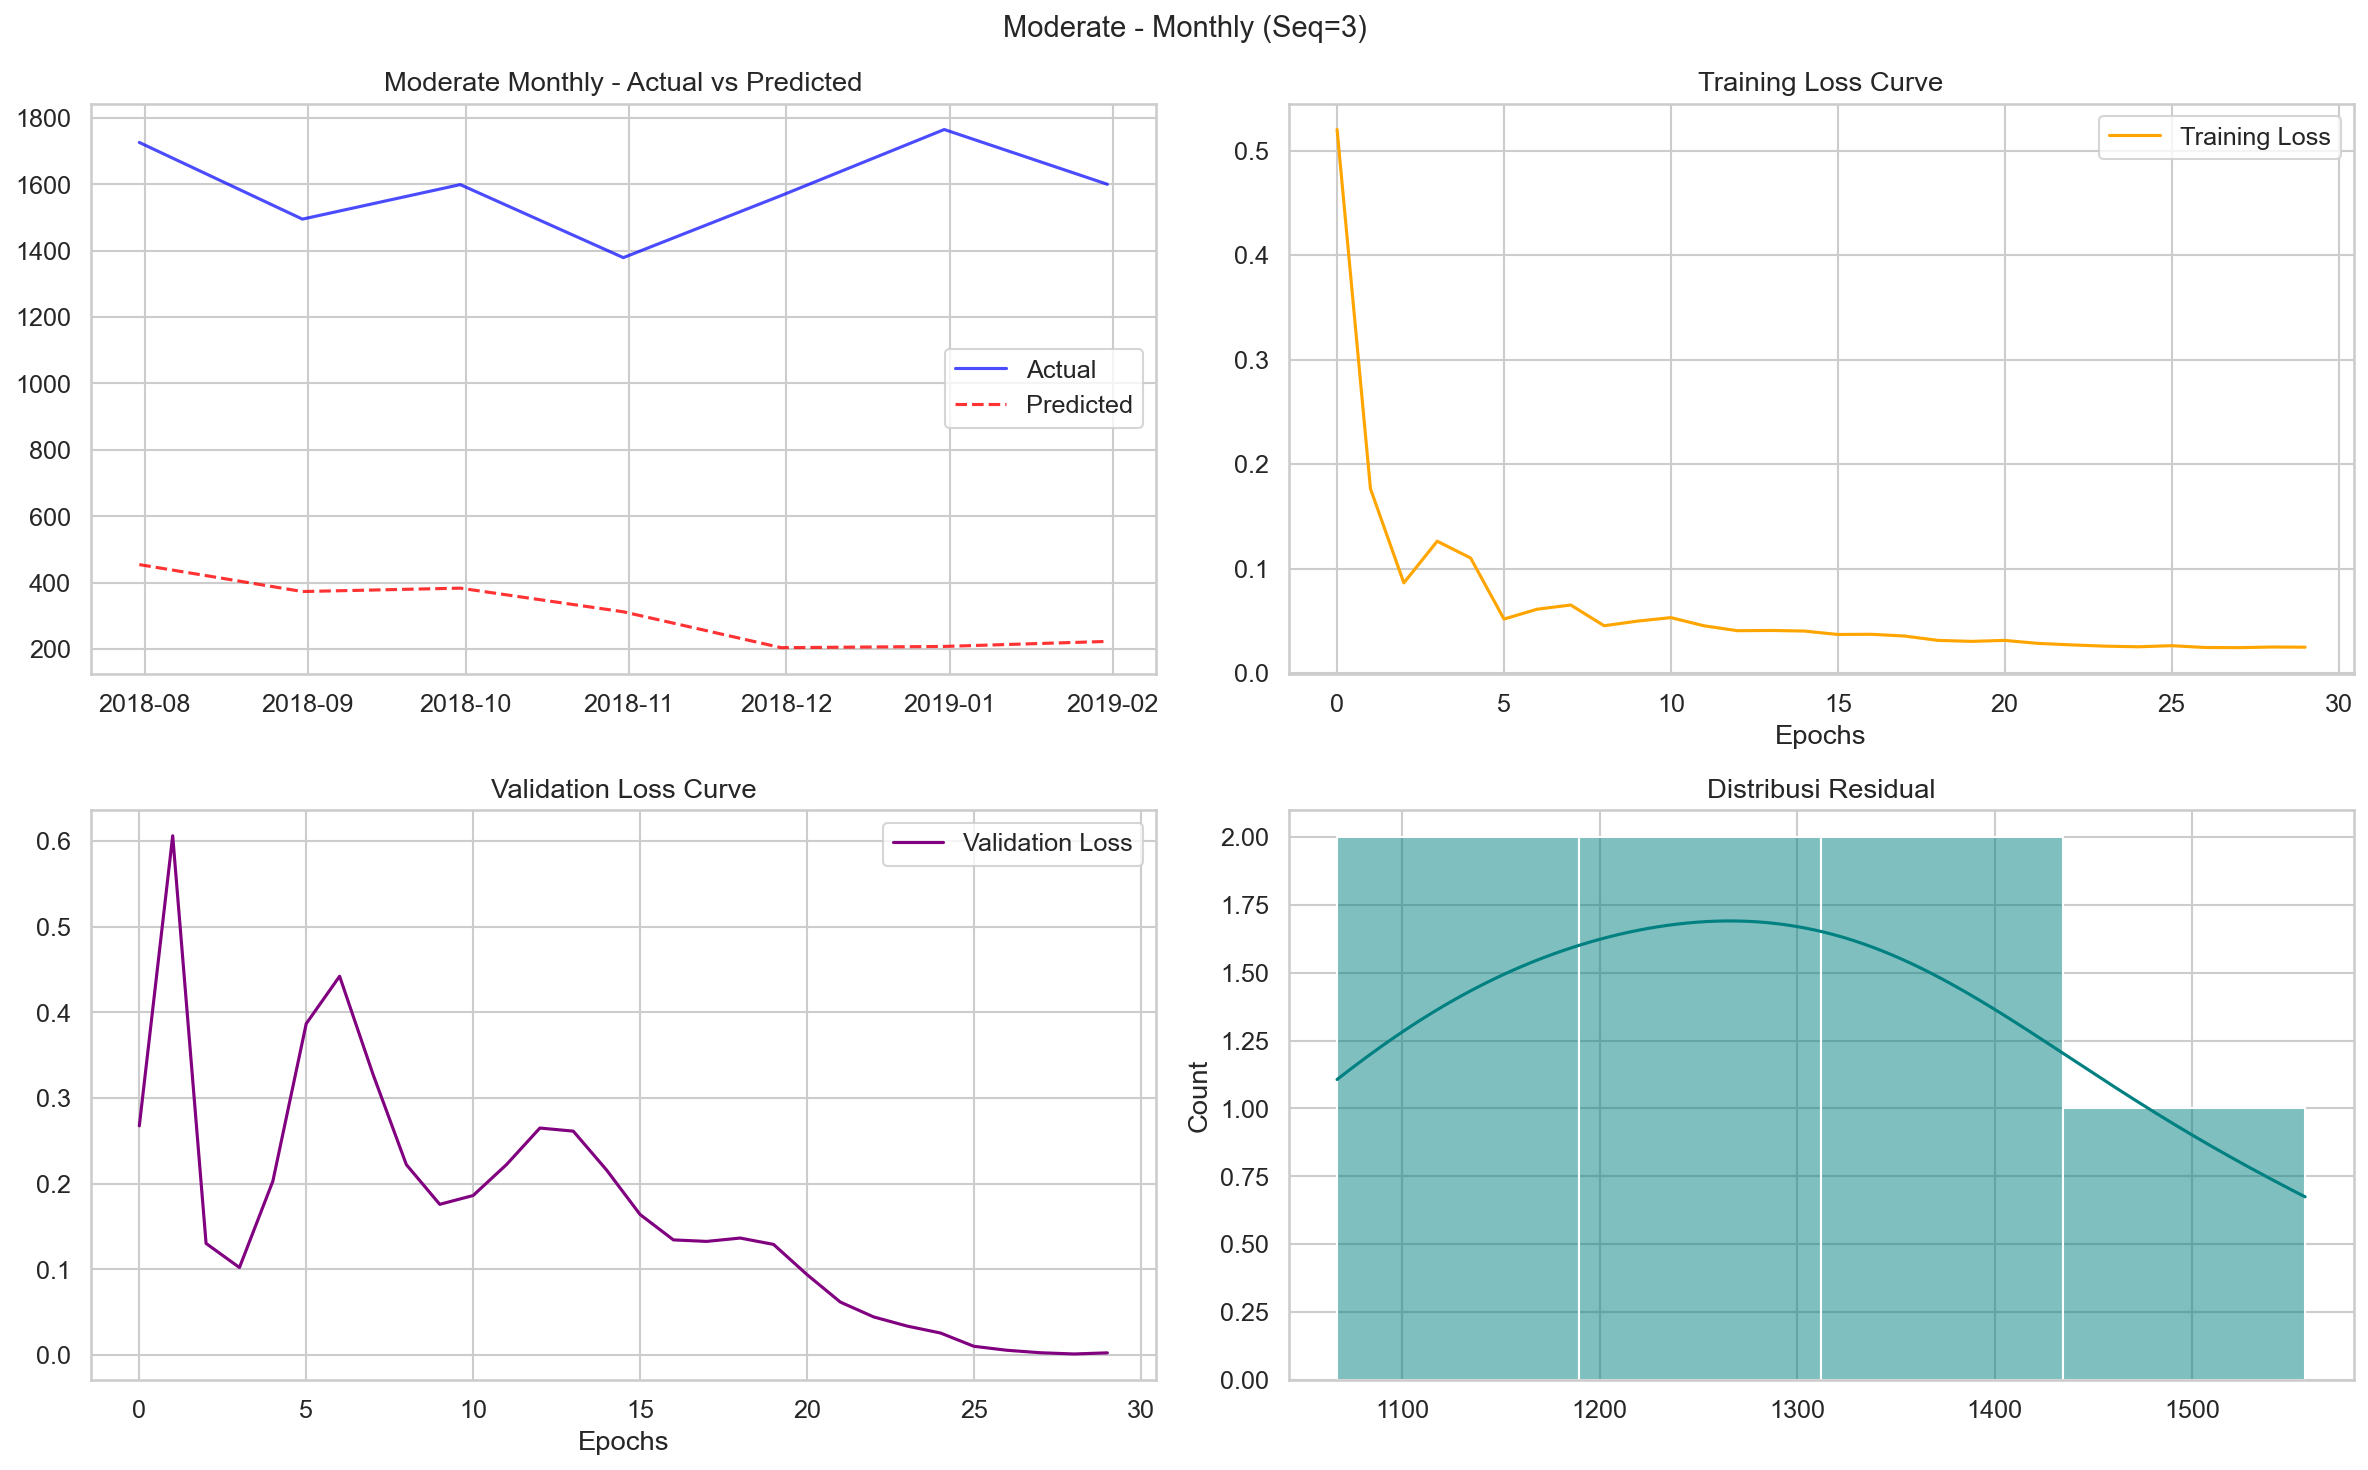

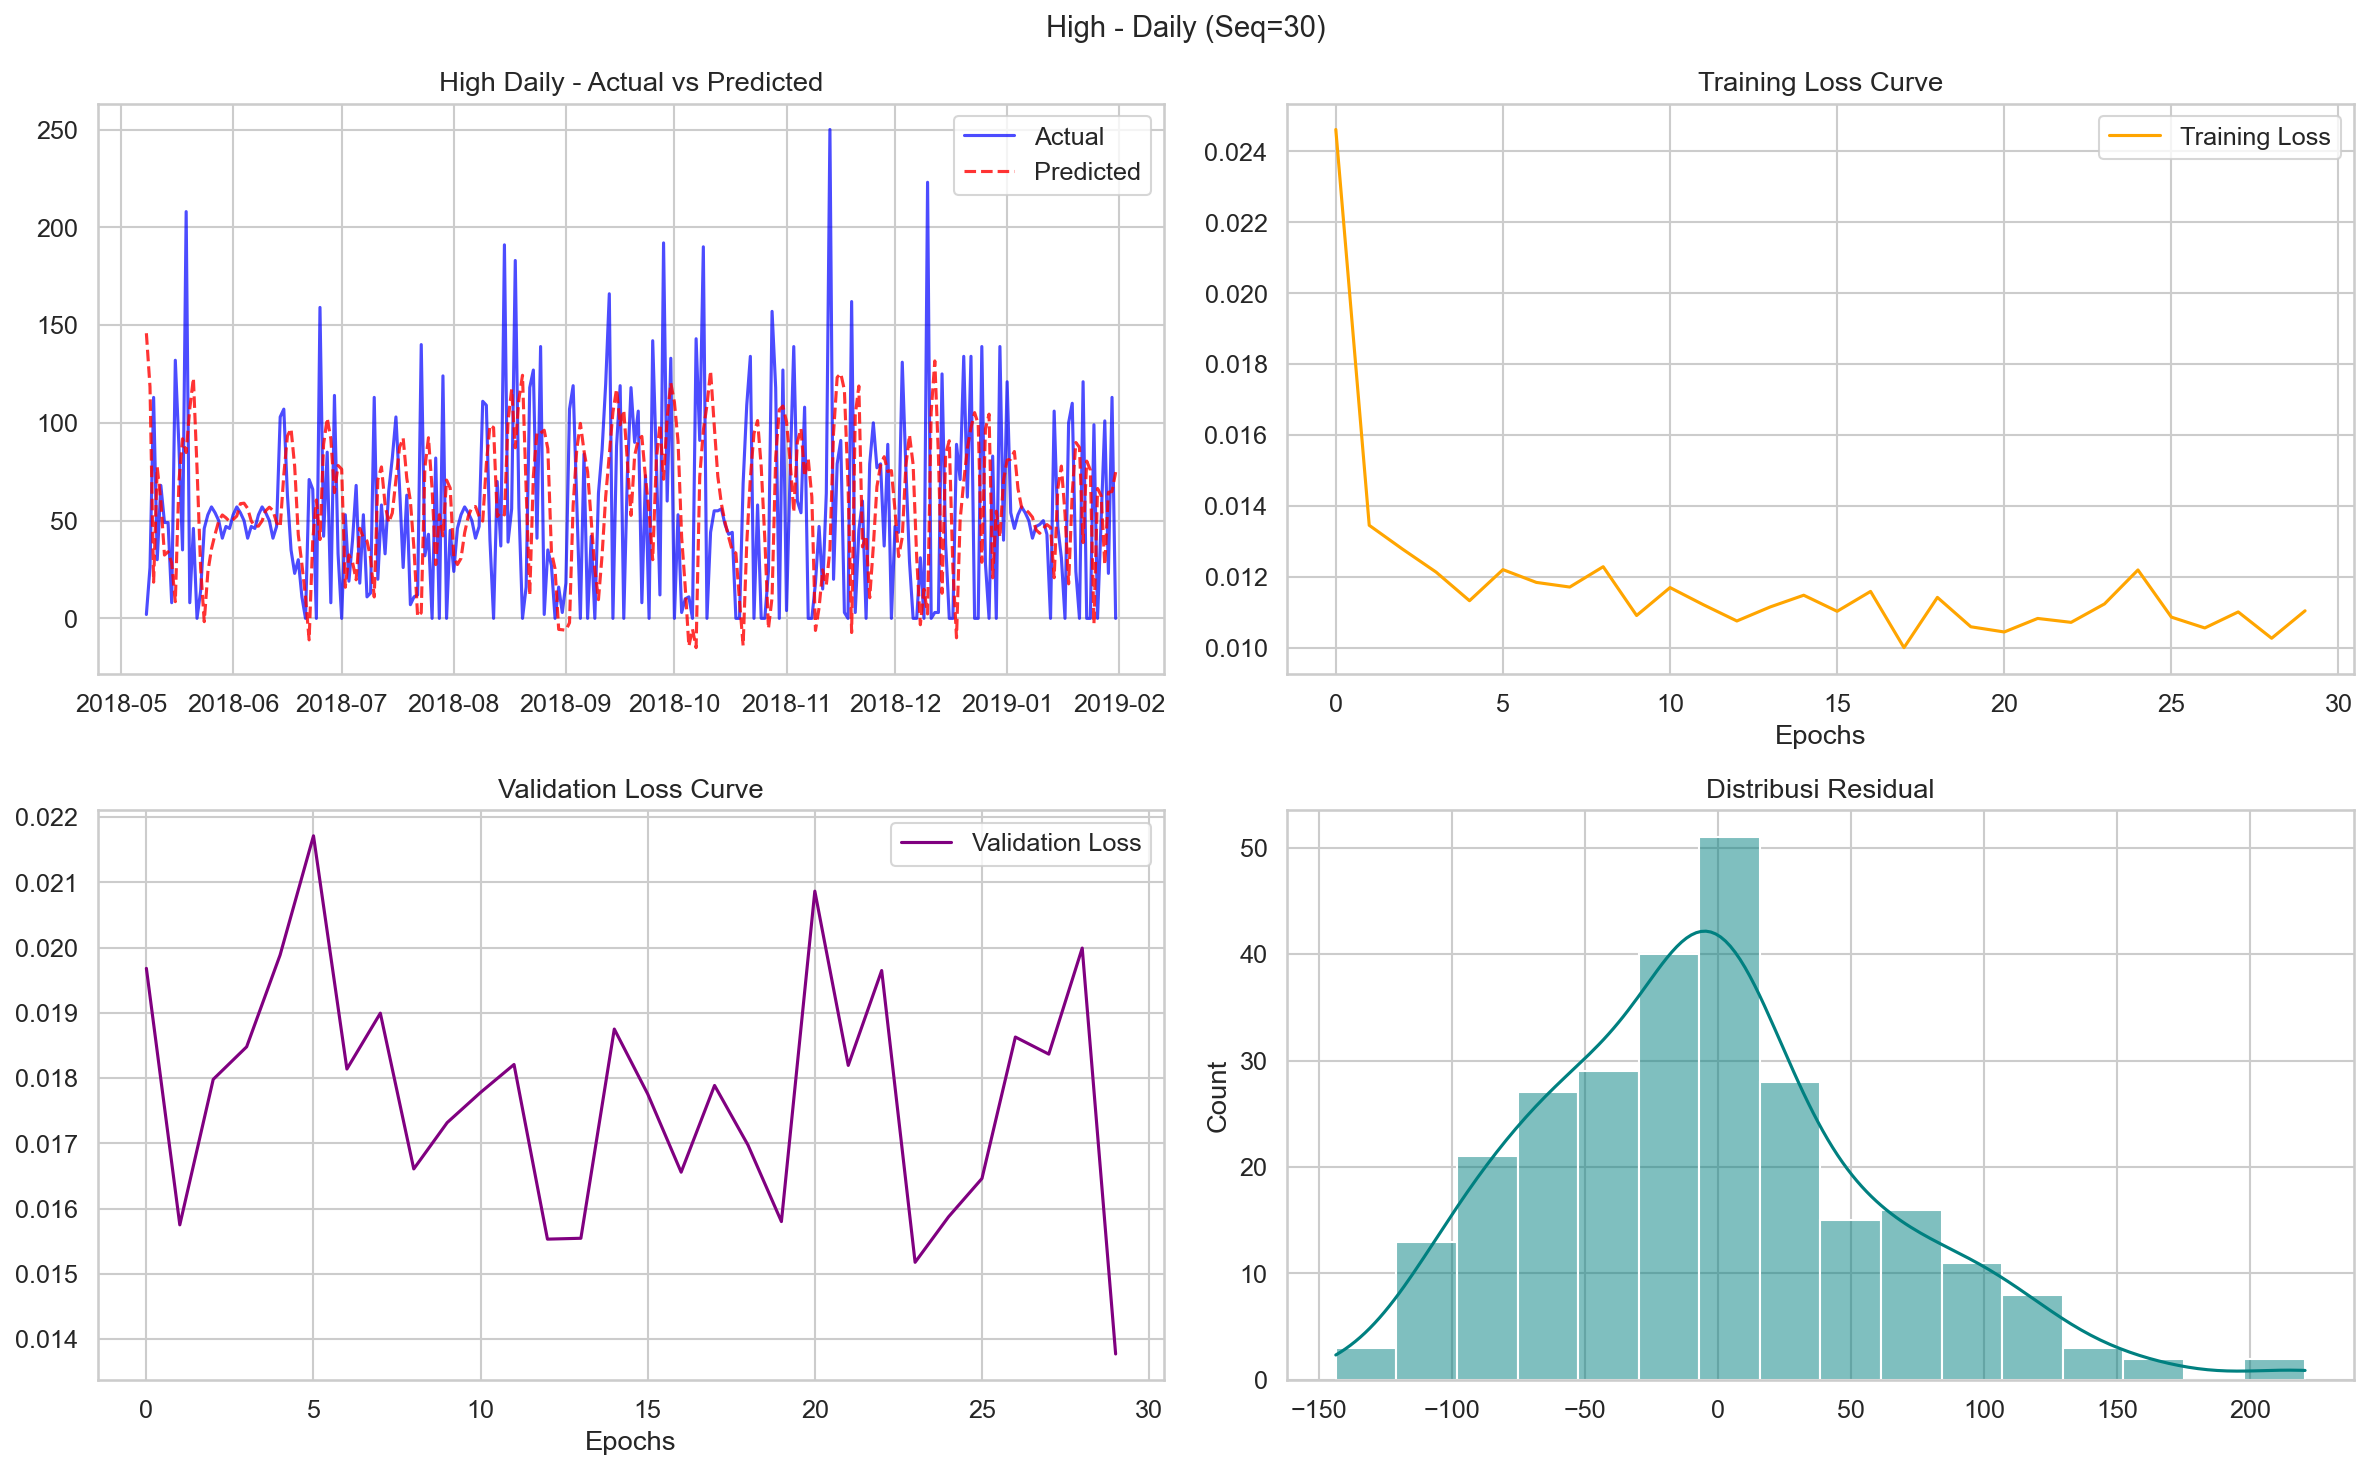

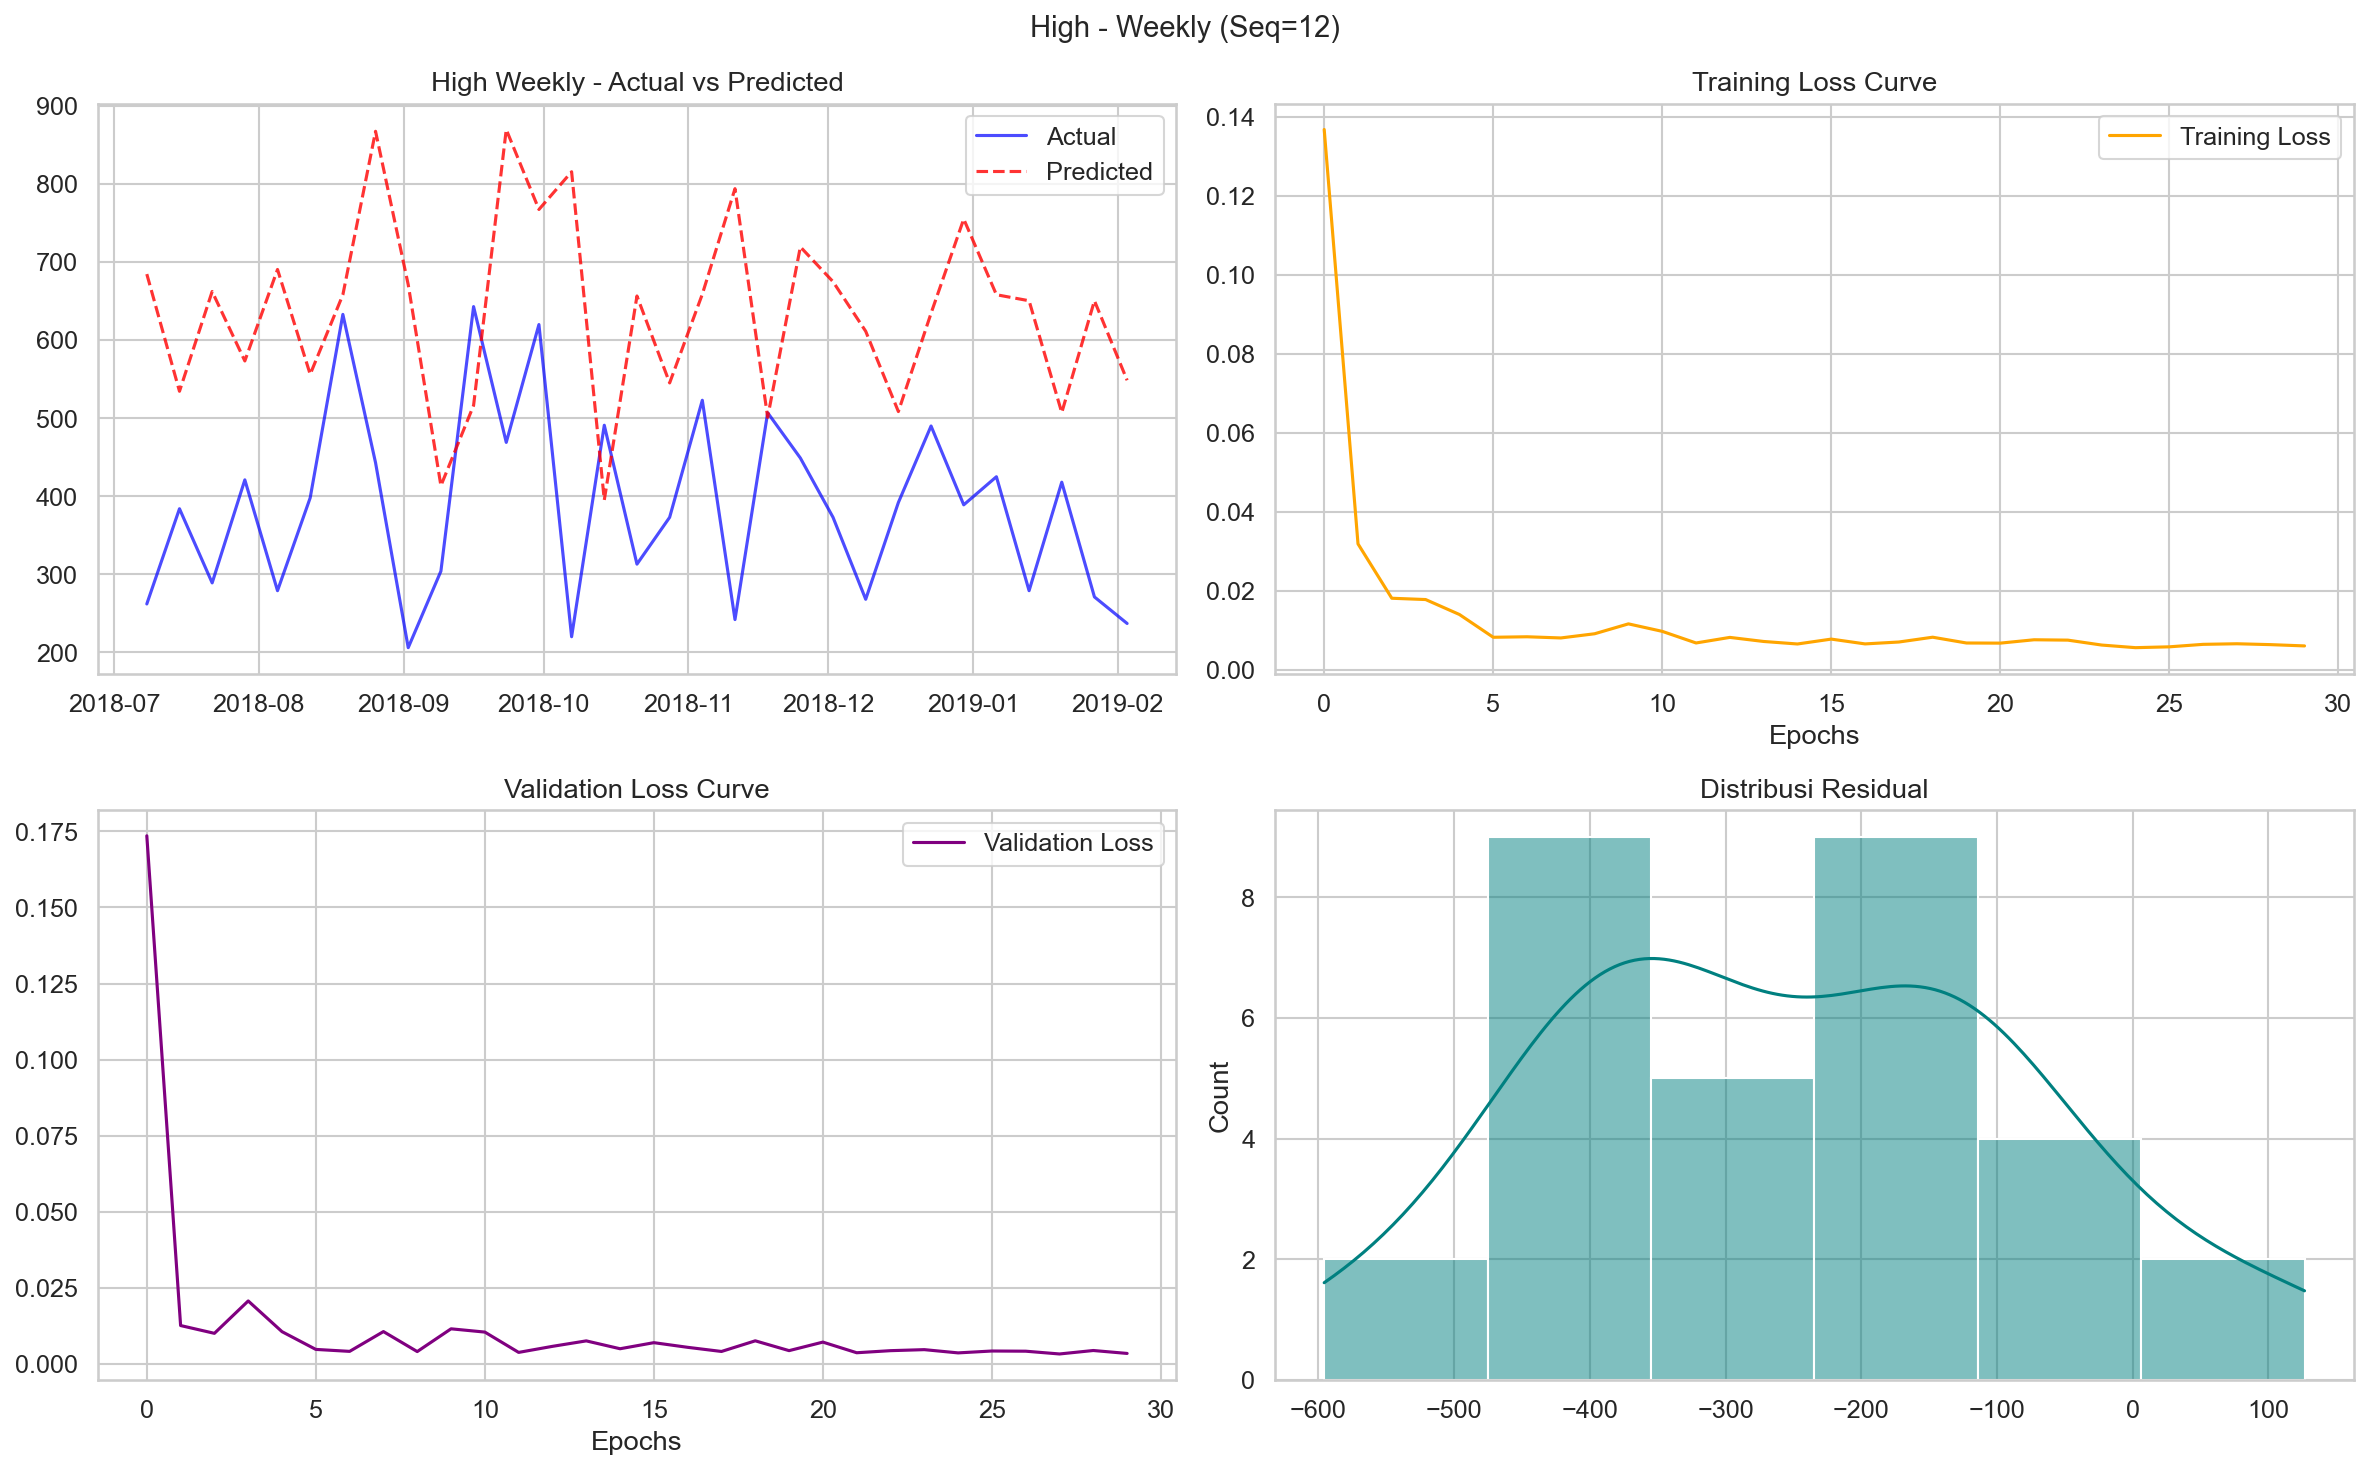

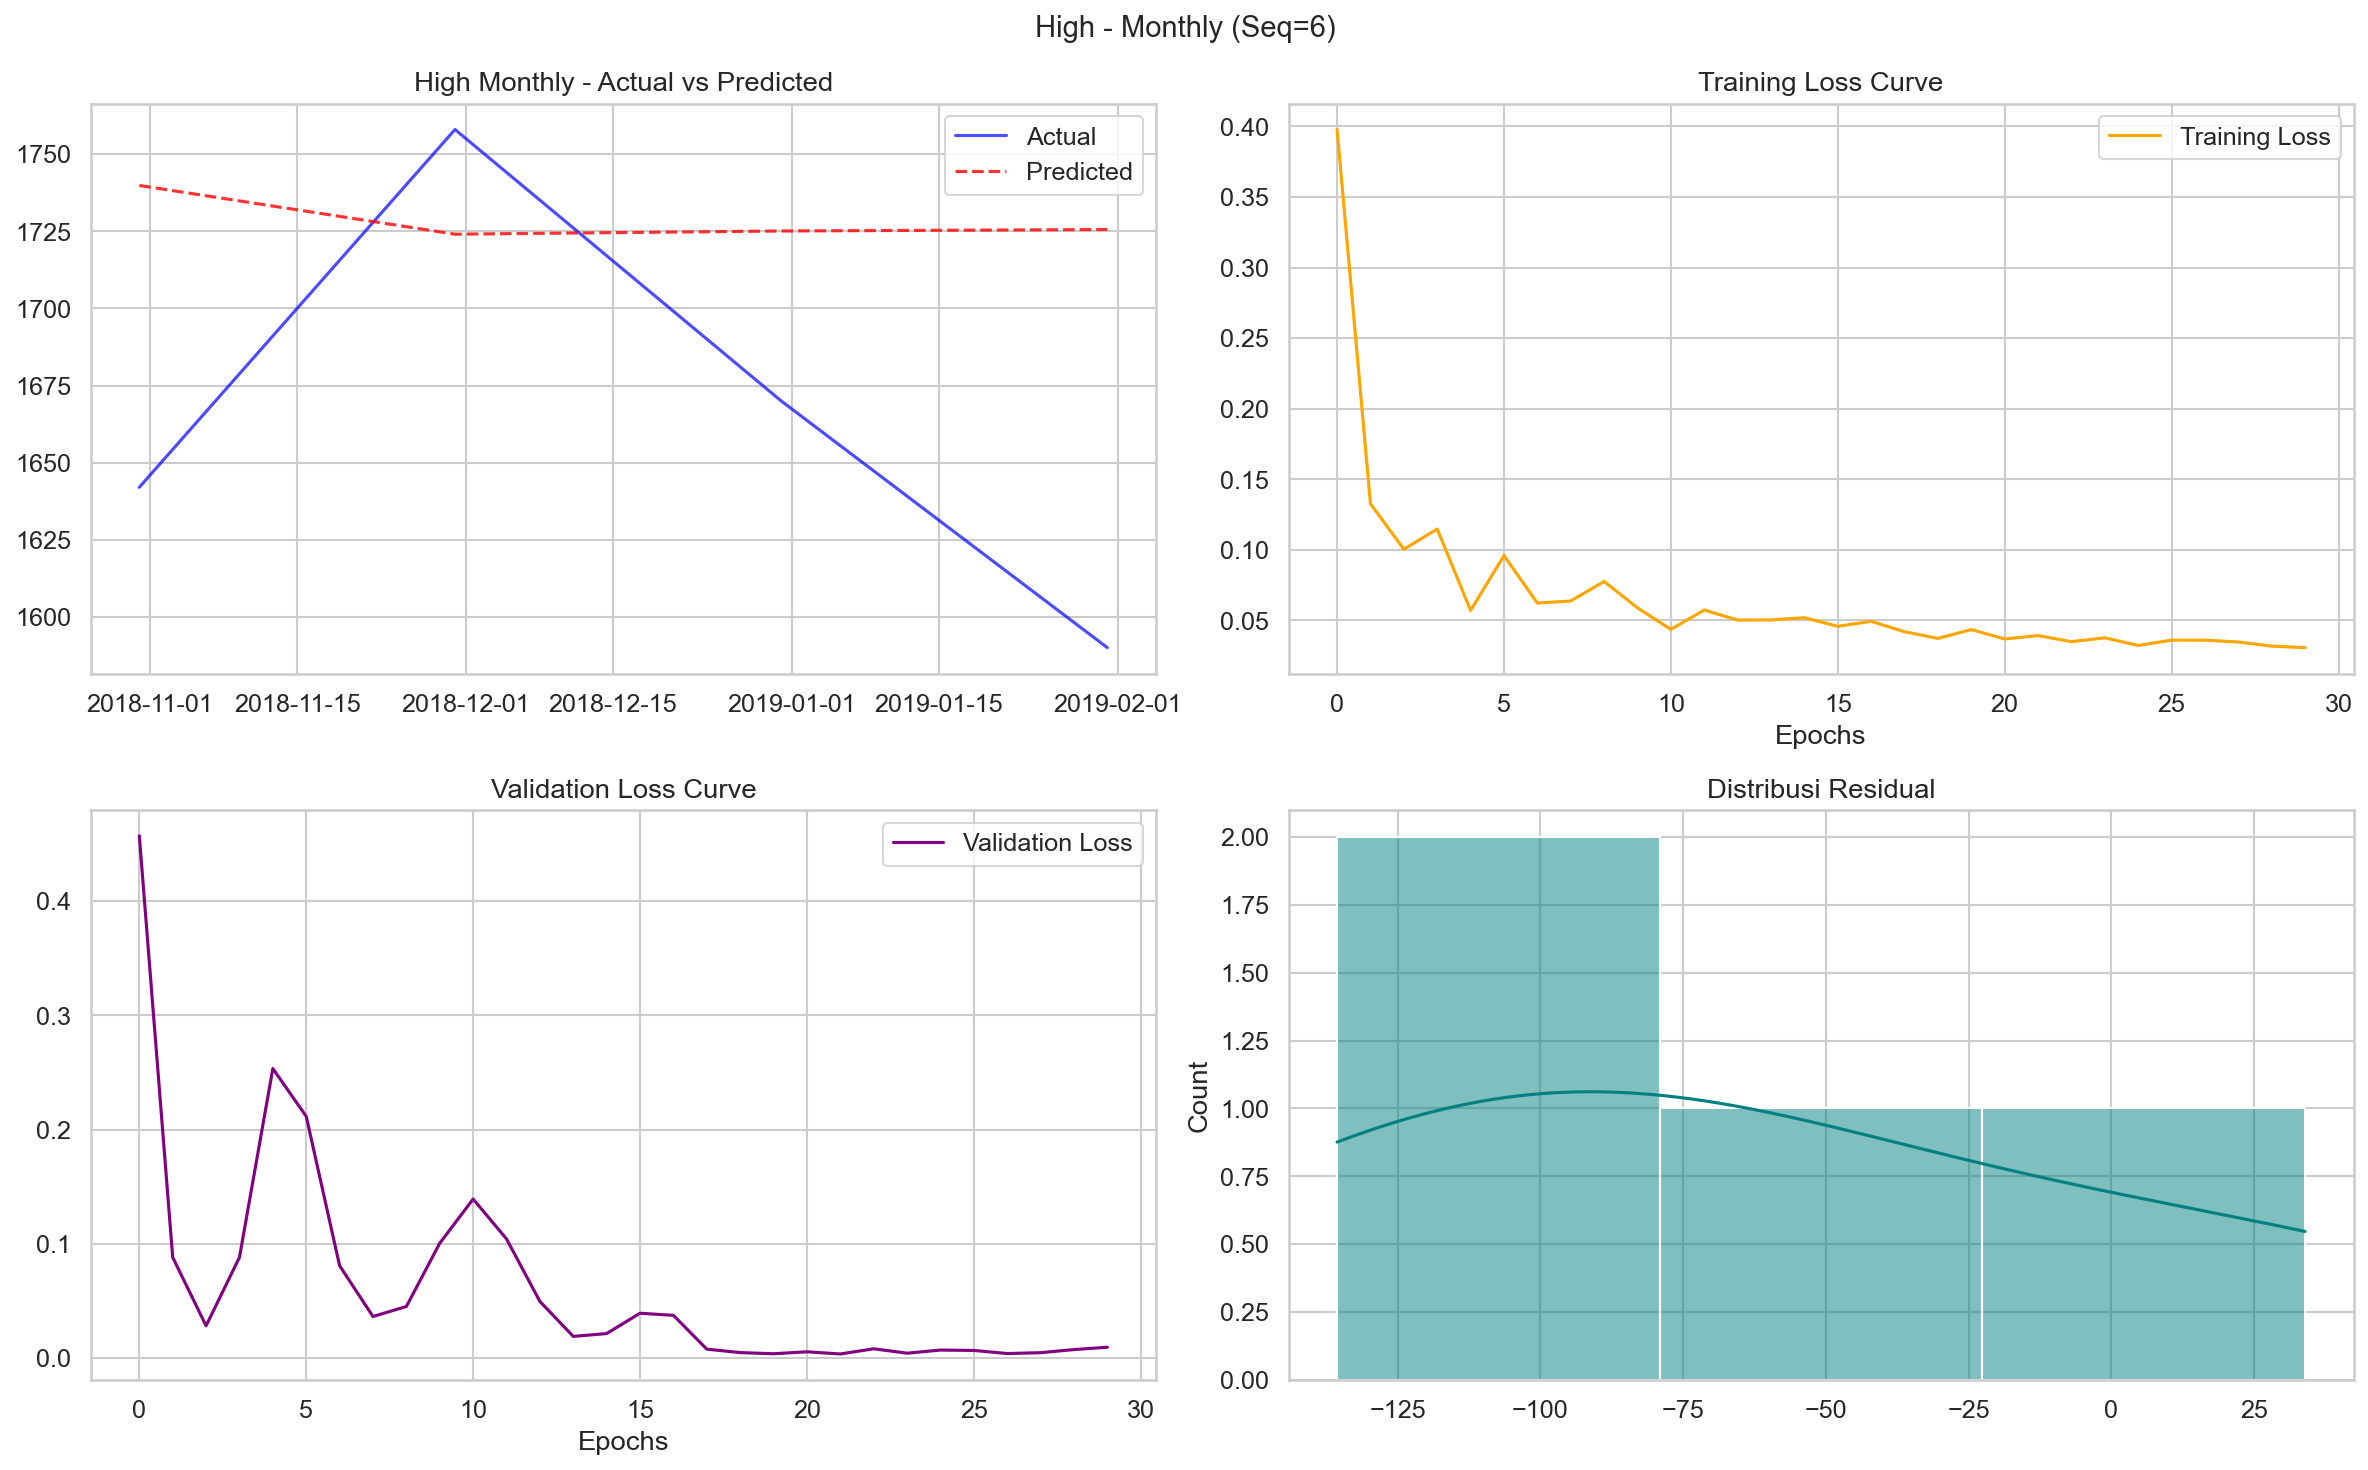

In [21]:
# For each best model per dataset, plot Actual vs Predicted + Loss + Residual
for info in all_best_infos:
    key = f"{info['Dataset']}_{info['Granularity']}"
    if key not in all_best_preds:
        continue
    preds = all_best_preds[key]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Actual vs Predicted
    axes[0, 0].plot(preds['Date'], preds['Actual'], label='Actual', alpha=0.7, color='blue')
    axes[0, 0].plot(preds['Date'], preds['Predicted'], label='Predicted', alpha=0.8, color='red', linestyle='--')
    axes[0, 0].set_title(f"{info['Dataset']} {info['Granularity']} - Actual vs Predicted")
    axes[0, 0].legend()
    
    # 2. Training Loss
    axes[0, 1].plot(info['Train_Losses'], label='Training Loss', color='orange')
    axes[0, 1].set_title('Training Loss Curve')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].legend()
    
    # 3. Validation Loss
    axes[1, 0].plot(info['Val_Losses'], label='Validation Loss', color='purple')
    axes[1, 0].set_title('Validation Loss Curve')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].legend()
    
    # 4. Residual Distribution
    residuals = preds['Actual'] - preds['Predicted']
    sns.histplot(residuals, kde=True, color='teal', ax=axes[1, 1])
    axes[1, 1].set_title('Distribusi Residual')
    
    plt.suptitle(f"{info['Dataset']} - {info['Granularity']} (Seq={info['Sequence_Length']})", fontsize=14)
    plt.tight_layout()
    safe_name = f"{info['Dataset'].lower()}_{info['Granularity'].lower()}"
    plt.show()

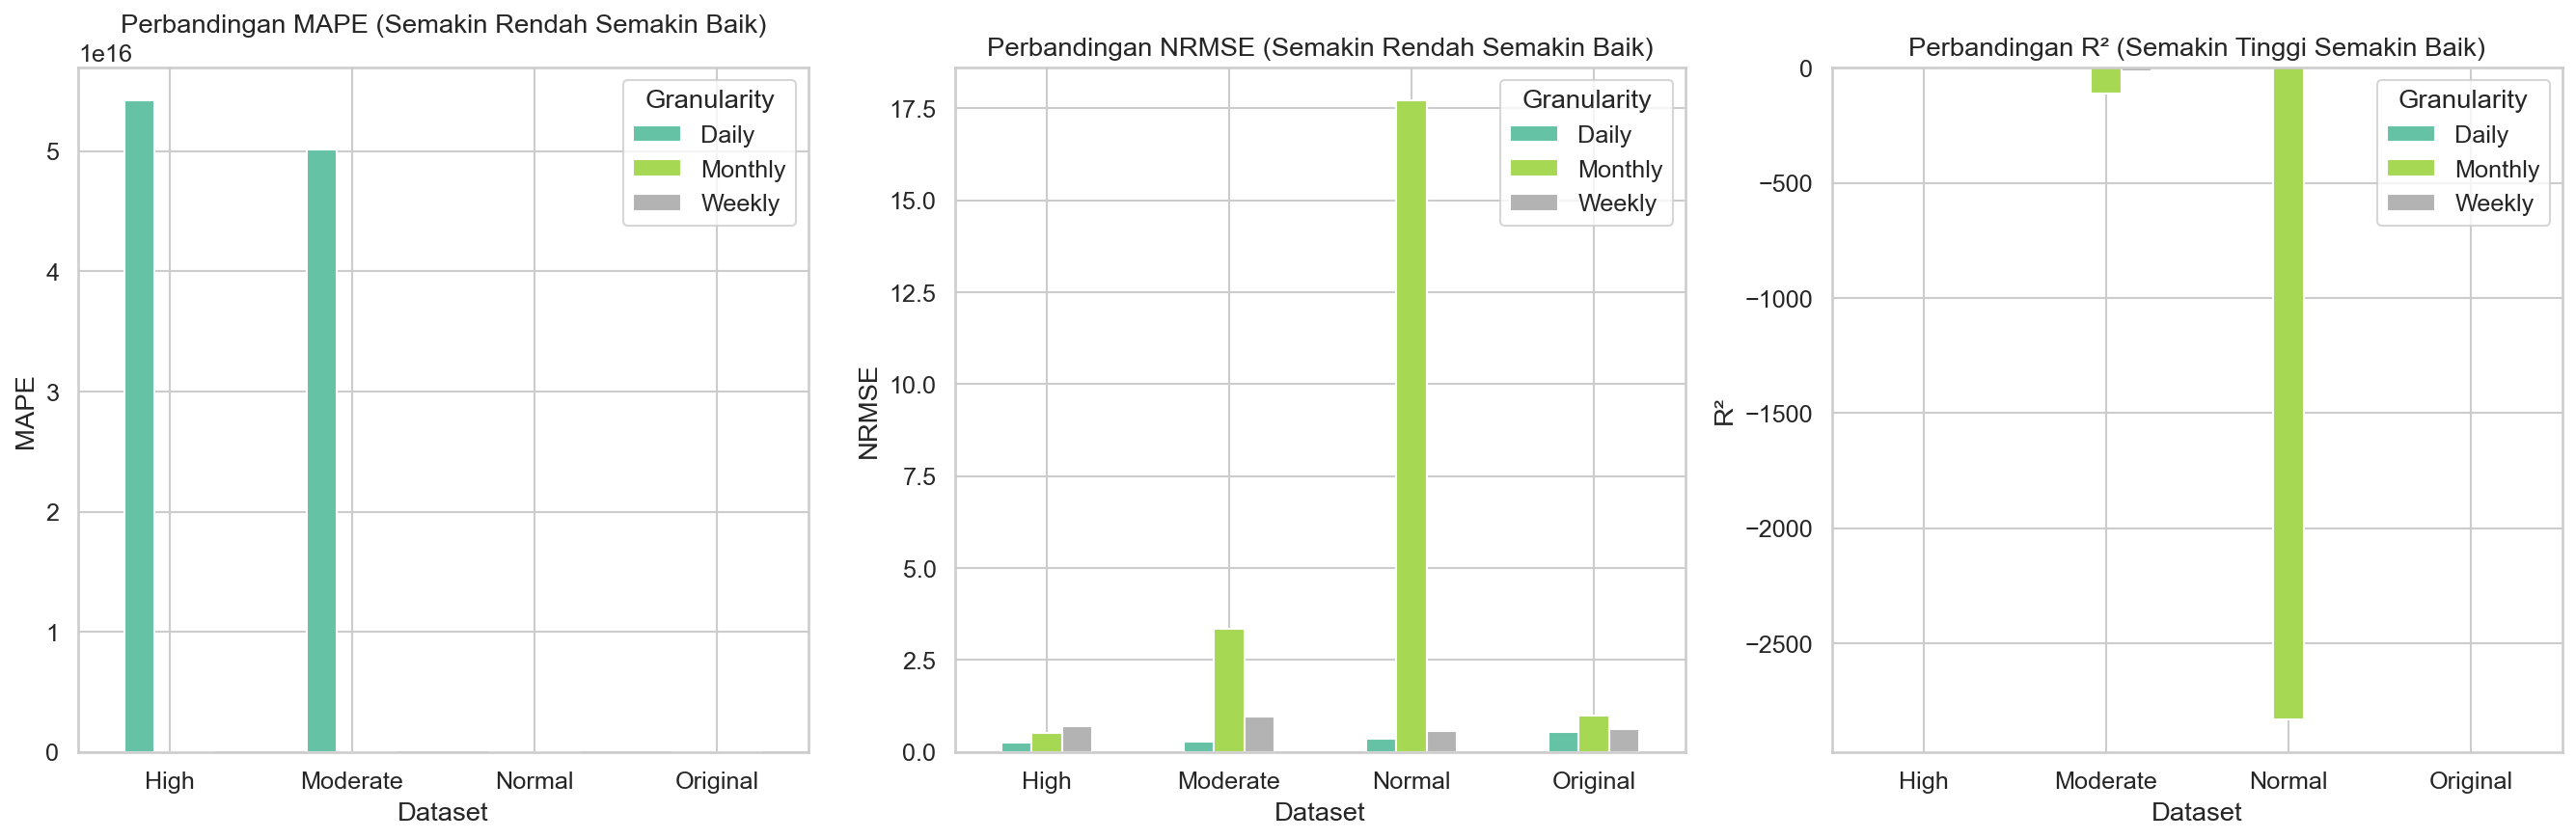

In [22]:
# Metric Comparison Dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# MAPE comparison
pivot_mape = df_results.pivot_table(index='Dataset', columns='Granularity', values='MAPE', aggfunc='min')
pivot_mape.plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Perbandingan MAPE (Semakin Rendah Semakin Baik)')
axes[0].set_ylabel('MAPE')
axes[0].tick_params(axis='x', rotation=0)

# NRMSE comparison
pivot_nrmse = df_results.pivot_table(index='Dataset', columns='Granularity', values='NRMSE', aggfunc='min')
pivot_nrmse.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Perbandingan NRMSE (Semakin Rendah Semakin Baik)')
axes[1].set_ylabel('NRMSE')
axes[1].tick_params(axis='x', rotation=0)

# R² comparison
pivot_r2 = df_results.pivot_table(index='Dataset', columns='Granularity', values='R2', aggfunc='max')
pivot_r2.plot(kind='bar', ax=axes[2], colormap='Set2')
axes[2].set_title('Perbandingan R² (Semakin Tinggi Semakin Baik)')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Ekspor Model Terbaik

In [23]:
# Save best model
if global_best_model_state:
    best_model = GRUModel()
    best_model.load_state_dict(global_best_model_state)
    
    model_path = 'data/predicted_v2/best_gru_model.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump({
            'model_state': global_best_model_state,
            'info': {k: v for k, v in global_best_info.items() if k not in ['Train_Losses', 'Val_Losses']}
        }, f)
    print(f"Model terbaik disimpan ke: {model_path}")

Model terbaik disimpan ke: data/predicted_v2/best_gru_model.pkl


In [24]:
report = f"""# Laporan Peramalan GRU V2 (Multi-Skenario)

## Konfigurasi Model
- Arsitektur: GRU (Hidden=64, Layers=2)
- Optimizer: Adam (LR=0.01)
- Epochs: 30
- Split: 80% Train / 20% Test (Kronologis)
- Scaler: MinMaxScaler (fit on train only)

## Metrik Utama
- **MAPE**: Mengukur galat dalam persentase, tidak terpengaruh skala data.
- **NRMSE**: RMSE dinormalisasi oleh rentang data, cocok untuk komparasi antar dataset berbeda.

## Hasil Terbaik
- Dataset: {overall_best['Dataset']}
- Granularitas: {overall_best['Granularity']}
- Sequence Length: {overall_best['Sequence_Length']}
- MAPE: {overall_best['MAPE']:.4f}
- NRMSE: {overall_best['NRMSE']:.4f}
- R²: {overall_best['R2']:.4f}
- RMSE: {overall_best['RMSE']:.2f}
- MAE: {overall_best['MAE']:.2f}

## Kesimpulan
Model GRU V2 menggunakan data sintetis berbasis dekomposisi musiman menunjukkan
performa yang berbeda secara signifikan dari GRU V1 (random sampling).
Data sintetis yang memiliki timeline diperluas dan skenario volatilitas
memberikan informasi temporal baru yang tidak tersedia di data asli.
"""

with open('data/predicted_v2/gru_report.md', 'w') as f:
    f.write(report)

print("Laporan disimpan ke: data/predicted_v2/gru_report.md")
print("\n=== Pipeline GRU V2 Selesai ===")

Laporan disimpan ke: data/predicted_v2/gru_report.md

=== Pipeline GRU V2 Selesai ===


## Task 1: Baseline Comparison (Naive & Moving Average)

In [25]:
# Evaluate naive and moving average for the overall best dataset & granularity
best_ds_name = overall_best['Dataset']
best_gran = overall_best['Granularity']
data_for_baseline = all_aggregations[best_ds_name][best_gran]['Demand'].values

# Split same as GRU
train_size = int(len(data_for_baseline) * 0.8)
test_data = data_for_baseline[train_size:]

# Naive Forecast: y(t) = y(t-1)
# For the test set, we need the last train point to predict the first test point
naive_preds = data_for_baseline[train_size-1 : len(data_for_baseline)-1]

# Moving Average Forecast: window=7
ma_window = 7
ma_preds = []
for i in range(len(test_data)):
    start_idx = train_size + i - ma_window
    window_data = data_for_baseline[start_idx : train_size + i]
    ma_preds.append(np.mean(window_data))
ma_preds = np.array(ma_preds)

actuals_bl = test_data

def eval_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'NRMSE': nrmse(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

baseline_results = [
    eval_metrics(actuals_bl, naive_preds, 'Naive (t-1)'),
    eval_metrics(actuals_bl, ma_preds, 'Moving Average (w=7)'),
    {
        'Model': 'Best GRU',
        'RMSE': overall_best['RMSE'],
        'MAE': overall_best['MAE'],
        'NRMSE': overall_best['NRMSE'],
        'R2': overall_best['R2']
    }
]

df_baselines = pd.DataFrame(baseline_results)
display(df_baselines.round(4))

,Model,RMSE,MAE,NRMSE,R2
0,Naive (t-1),79.0848,58.3913,0.2785,-1.2559
1,Moving Average (w=7),56.7124,44.3622,0.1997,-0.1601
2,Best GRU,63.3731,49.0748,0.2535,-0.6745


## Task 2: Sequence Length Analysis

In [26]:
# Aggregate results to see how sequence length affects NRMSE
seq_analysis = df_results.groupby(['Granularity', 'Sequence_Length'])['NRMSE'].mean().reset_index()
display(seq_analysis.pivot(index='Sequence_Length', columns='Granularity', values='NRMSE').round(4))
print("Interpretasi: Sequence length dengan rata-rata NRMSE terendah menunjukkan memori historis optimal.")

Granularity,Daily,Monthly,Weekly
Sequence_Length,,,
3,NaN,5.8961,NaN
4,NaN,NaN,0.7631
6,NaN,2313.7718,NaN
7,0.3830,NaN,NaN
8,NaN,NaN,0.8387
12,NaN,NaN,0.7955
14,0.4806,NaN,NaN
30,0.4014,NaN,NaN


Interpretasi: Sequence length dengan rata-rata NRMSE terendah menunjukkan memori historis optimal.


## Task 3: Error Analysis

,Mean Error,Median Error,Std Error,Max Error,Min Error
0,-4.6192,-6.8624,63.3223,220.732193,-143.813705


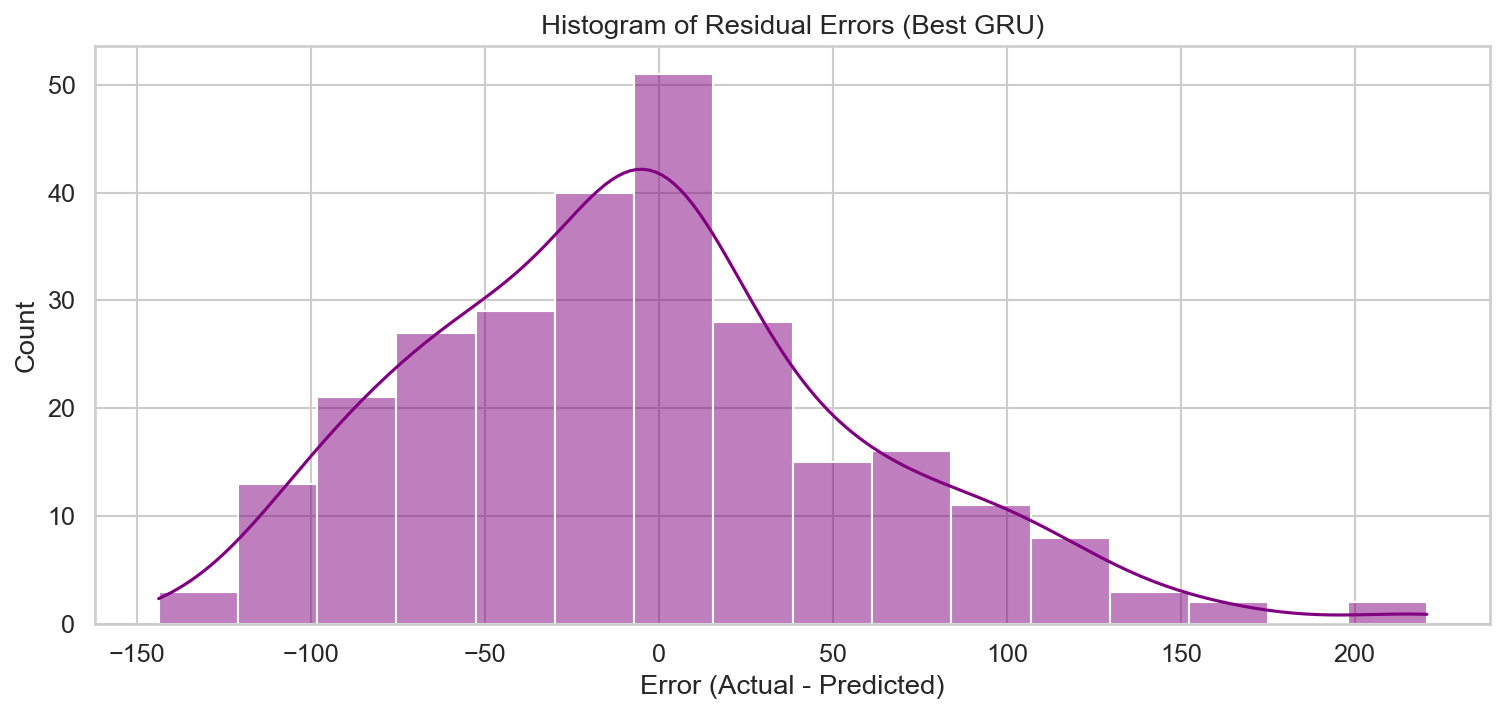

In [27]:
# Extract actuals and preds for the overall best model
best_key = f"{best_ds_name}_{best_gran}"
best_pred_df = all_best_preds[best_key]

errors = best_pred_df['Actual'] - best_pred_df['Predicted']

error_stats = {
    'Mean Error': errors.mean(),
    'Median Error': errors.median(),
    'Std Error': errors.std(),
    'Max Error': errors.max(),
    'Min Error': errors.min()
}
display(pd.DataFrame([error_stats]).round(4))

sns.histplot(errors, kde=True, color='purple')
plt.title('Histogram of Residual Errors (Best GRU)')
plt.xlabel('Error (Actual - Predicted)')
plt.show()

## Task 4: Stability Test (5 Runs)

In [28]:
# Run the best configuration 5 times with different seeds
stability_results = []
seeds = [42, 100, 2023, 777, 999]

gran_data_best = all_aggregations[best_ds_name][best_gran]
best_seq = overall_best['Sequence_Length']

for i, s in enumerate(seeds):
    # Set seed
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    
    # Train
    res, info, _, _ = train_gru_pipeline(
        gran_data_best, [best_seq], best_ds_name, best_gran, epochs=30
    )
    if info:
        stability_results.append({
            'Run': i+1,
            'Seed': s,
            'NRMSE': info['NRMSE'],
            'MAE': info['MAE']
        })

df_stability = pd.DataFrame(stability_results)
display(df_stability.round(4))

print("=== Ringkasan Stabilitas ===")
print(f"Mean NRMSE: {df_stability['NRMSE'].mean():.4f}")
print(f"Std NRMSE: {df_stability['NRMSE'].std():.4f}")
print(f"Mean MAE: {df_stability['MAE'].mean():.4f}")
print(f"Std MAE: {df_stability['MAE'].std():.4f}")

,Run,Seed,NRMSE,MAE
0,1,42,0.3122,59.6061
1,2,100,0.3674,67.5437
2,3,2023,0.4621,90.8563
3,4,777,0.3044,60.0965
4,5,999,0.3024,59.6076


=== Ringkasan Stabilitas ===
Mean NRMSE: 0.3497
Std NRMSE: 0.0682
Mean MAE: 67.5420
Std MAE: 13.4622


## Task 5: Dataset Comparison & Export

In [29]:
# Compare the 4 datasets (using their best model)
df_ds_comp = best_per_dataset[['Dataset', 'RMSE', 'MAE', 'NRMSE', 'R2']]
display(df_ds_comp.round(4))

print("Interpretasi: Dataset terbaik dipilih berdasarkan NRMSE terendah dan kemampuan model menangani volatilitas.")

# Export
df_ds_comp.to_csv('data/predicted_v2/gru_evaluation_summary.csv', index=False)
print("Ringkasan evaluasi GRU disimpan ke: data/predicted_v2/gru_evaluation_summary.csv")

,Dataset,RMSE,MAE,NRMSE,R2
26,High,63.3731,49.0748,0.2535,-0.6745
16,Moderate,62.6212,50.6746,0.2940,-0.9568
10,Normal,52.2472,45.6838,0.3603,-2.0295
0,Original,221.7419,179.1333,0.5448,-1.3935


Interpretasi: Dataset terbaik dipilih berdasarkan NRMSE terendah dan kemampuan model menangani volatilitas.
Ringkasan evaluasi GRU disimpan ke: data/predicted_v2/gru_evaluation_summary.csv
